## Imports

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../../')

In [3]:
import pickle
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.signal import correlate
import tools.viz.utilityTools as vizutils

In [13]:
# ── Parameters — edit these to select what to plot ───────────────────────────
RESULTS_DIR  = Path('/data/equake_results/lagged_kin_dec_all_kp/')
AREA         = 'SSp'

BASELINE_S   = (-0.8, -0.1)
SPAGHETTI_S  = (-0.1,  0.3)
LAG_RANGE    = (-150, 150)    # ms — change to explore (e.g. (-100, 100))

In [14]:
# ── Discover available sessions ───────────────────────────────────────────────
files    = sorted(RESULTS_DIR.glob(f'lagged_dec_{AREA}_*.pkl'))
SESSIONS = [f.stem.replace(f'lagged_dec_{AREA}_', '') for f in files]
print(f'Found {len(files)} files:')
for s in SESSIONS:
    print(f'  {s}')

Found 9 files:
  M061_2025_03_04_10_00
  M061_2025_03_05_14_00
  M061_2025_03_06_14_00
  M062_2025_03_20_14_00
  M062_2025_03_21_14_00
  M063_2025_03_13_14_00
  M063_2025_03_14_15_30
  M078_2025_08_06_15_00
  M086_2025_12_10_15_00


In [15]:
# ── Load all sessions ─────────────────────────────────────────────────────────
def _load_session(session):
    pkl_path = RESULTS_DIR / f'lagged_dec_{AREA}_{session}.pkl'
    with open(pkl_path, 'rb') as fh:
        raw = pickle.load(fh)
    if '_meta' in raw:
        meta    = raw.pop('_meta')
        lags_ms = meta['lags_s'] * 1000
    else:
        n_lags  = next(iter(next(iter(raw.values())).values())).shape[0]
        lags_ms = np.linspace(-250, 250, n_lags)
        print(f'  WARNING: no _meta in {session}')
    return raw, lags_ms

all_data = {}
all_lags = {}   # per-session lag arrays
for sess in SESSIONS:
    try:
        data, lags_ms = _load_session(sess)
        all_data[sess] = data
        all_lags[sess] = lags_ms
        print(f'OK   {sess}  keypoints={len(data)}  lags={lags_ms[0]:.0f}→{lags_ms[-1]:.0f} ({len(lags_ms)})')
    except FileNotFoundError:
        print(f'SKIP {sess}')

KEYPOINTS   = list(next(iter(all_data.values())).keys())
_animals    = sorted(set(s[:4] for s in all_data))
ANIMAL_COLORS = {a: c for a, c in zip(_animals, plt.cm.tab10.colors)}
SPAGHETTI_SESSION = list(all_data.keys())[0]

print(f'\nKPs  : {KEYPOINTS}')
print(f'Spaghetti session: {SPAGHETTI_SESSION}')

OK   M061_2025_03_04_10_00  keypoints=19  lags=-250→250 (51)
OK   M061_2025_03_05_14_00  keypoints=19  lags=-250→250 (51)
OK   M061_2025_03_06_14_00  keypoints=19  lags=-250→250 (51)
OK   M062_2025_03_20_14_00  keypoints=19  lags=-150→150 (31)
OK   M062_2025_03_21_14_00  keypoints=19  lags=-150→150 (31)
OK   M063_2025_03_13_14_00  keypoints=19  lags=-250→250 (51)
OK   M063_2025_03_14_15_30  keypoints=19  lags=-250→250 (51)
OK   M078_2025_08_06_15_00  keypoints=19  lags=-150→150 (31)
OK   M086_2025_12_10_15_00  keypoints=19  lags=-150→150 (31)

KPs  : ['hip_center', 'left_ankle', 'left_elbow', 'left_foot', 'left_knee', 'left_paw', 'left_shoulder', 'left_wrist', 'right_ankle', 'right_elbow', 'right_foot', 'right_knee', 'right_paw', 'right_shoulder', 'right_wrist', 'shoulder_center', 'tail_base', 'tail_middle', 'tail_tip']
Spaghetti session: M061_2025_03_04_10_00


In [16]:
# ── Helper: compute AUC time series for one session × keypoint ───────────────
def _make_masks(lags_ms):
    """Return (lag_mask, lags_masked, past_mask, future_mask) for a session's lag array."""
    lag_mask    = (lags_ms >= LAG_RANGE[0]) & (lags_ms <= LAG_RANGE[1])
    lags_masked = lags_ms[lag_mask]
    past_mask   = lags_masked <  0
    future_mask = lags_masked >  0
    return lag_mask, lags_masked, past_mask, future_mask

def _auc_timeseries(session_data, keypoint, lags_ms):
    lag_mask, lags_masked, past_mask, future_mask = _make_masks(lags_ms)
    res   = session_data[keypoint]
    t_all = np.array(sorted(res.keys()))
    ap, af = [], []
    for ti in t_all:
        curve = res[ti].mean(-1)[lag_mask]
        ap.append(np.trapz(curve[past_mask],   lags_masked[past_mask]))
        af.append(np.trapz(curve[future_mask], lags_masked[future_mask]))
    return t_all, np.array(ap), np.array(af)

def _baseline_r2(session_data, keypoint, lags_ms):
    lag_mask, *_ = _make_masks(lags_ms)
    res   = session_data[keypoint]
    t_all = np.array(sorted(res.keys()))
    bl    = (t_all >= BASELINE_S[0]) & (t_all < BASELINE_S[1])
    return np.array([res[ti].mean(-1)[lag_mask] for ti in t_all[bl]]).mean(0)

Session: M078_2025_08_06_15_00  lags: -150→140 ms  lag0=0.0 ms


/tmp/ipykernel_1318930/4260965959.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


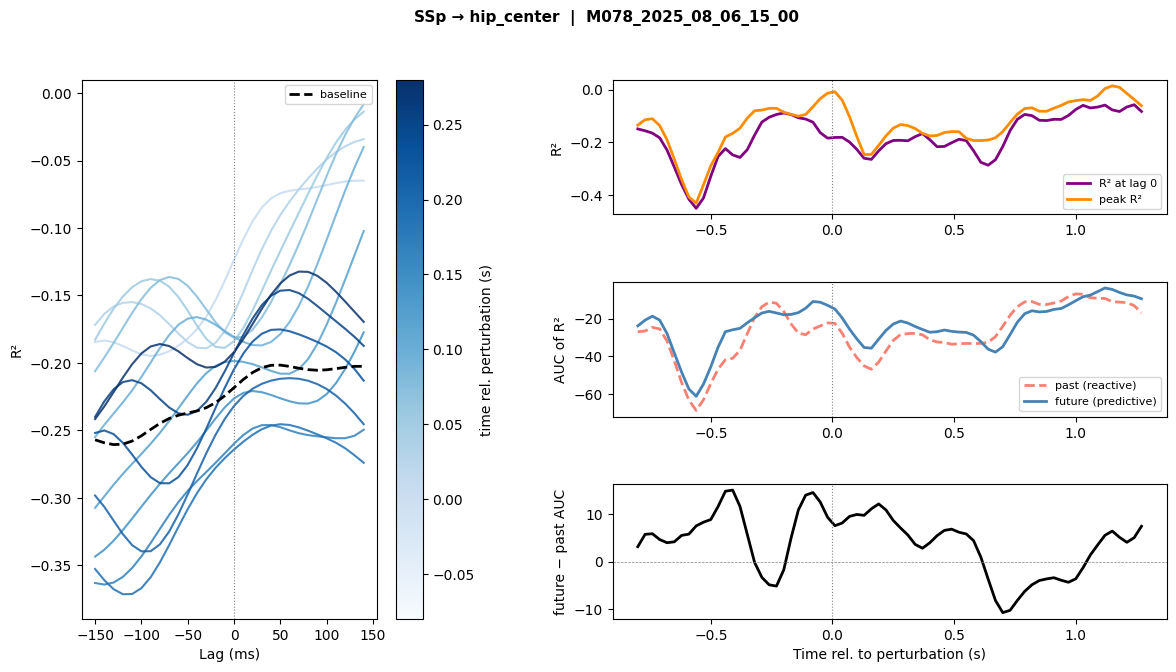

hip_center            peak diff=-10.791 at t=0.70s


/tmp/ipykernel_1318930/4260965959.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


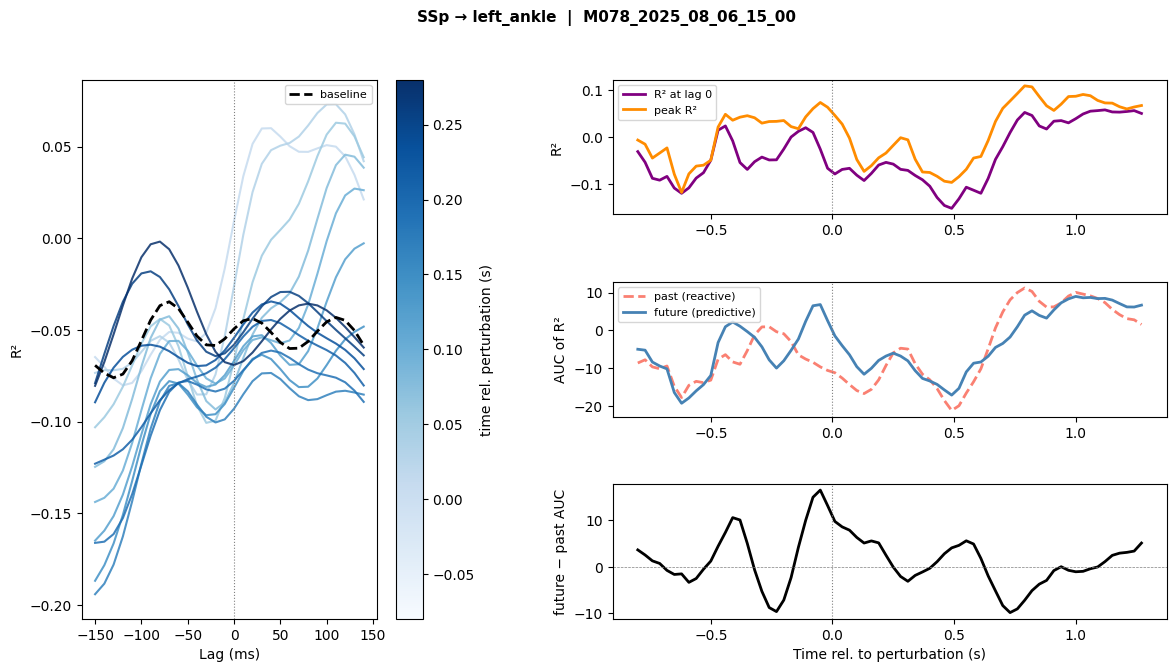

left_ankle            peak diff=-9.817 at t=0.73s


/tmp/ipykernel_1318930/4260965959.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


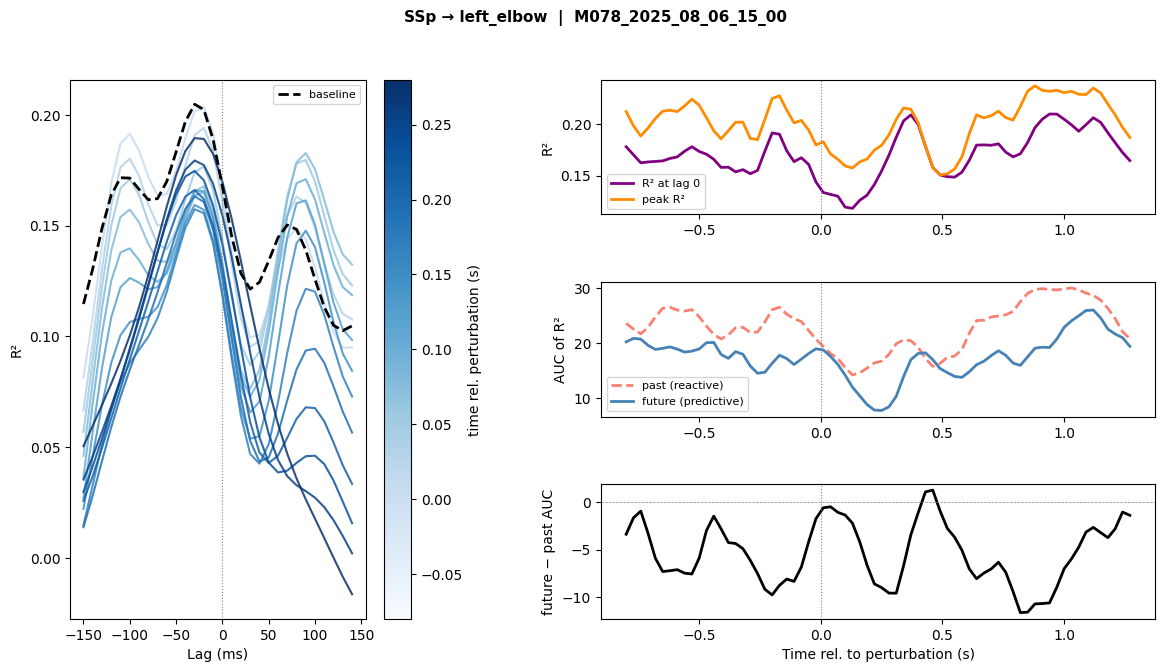

left_elbow            peak diff=-11.581 at t=0.82s


/tmp/ipykernel_1318930/4260965959.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


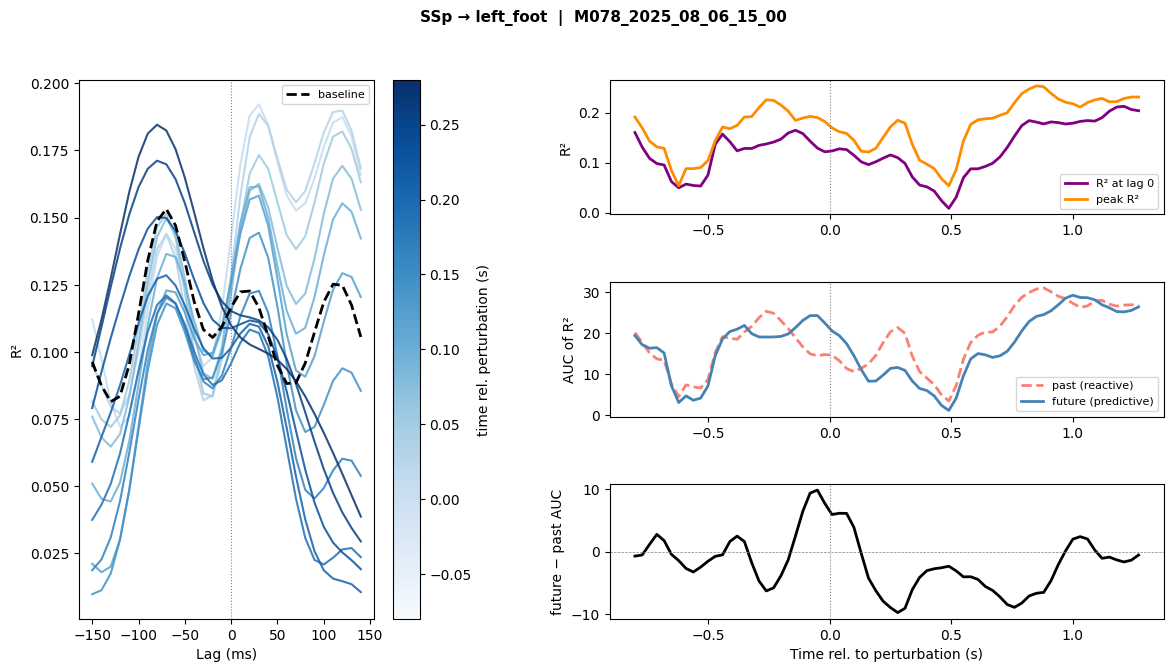

left_foot             peak diff=-9.723 at t=0.28s


/tmp/ipykernel_1318930/4260965959.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


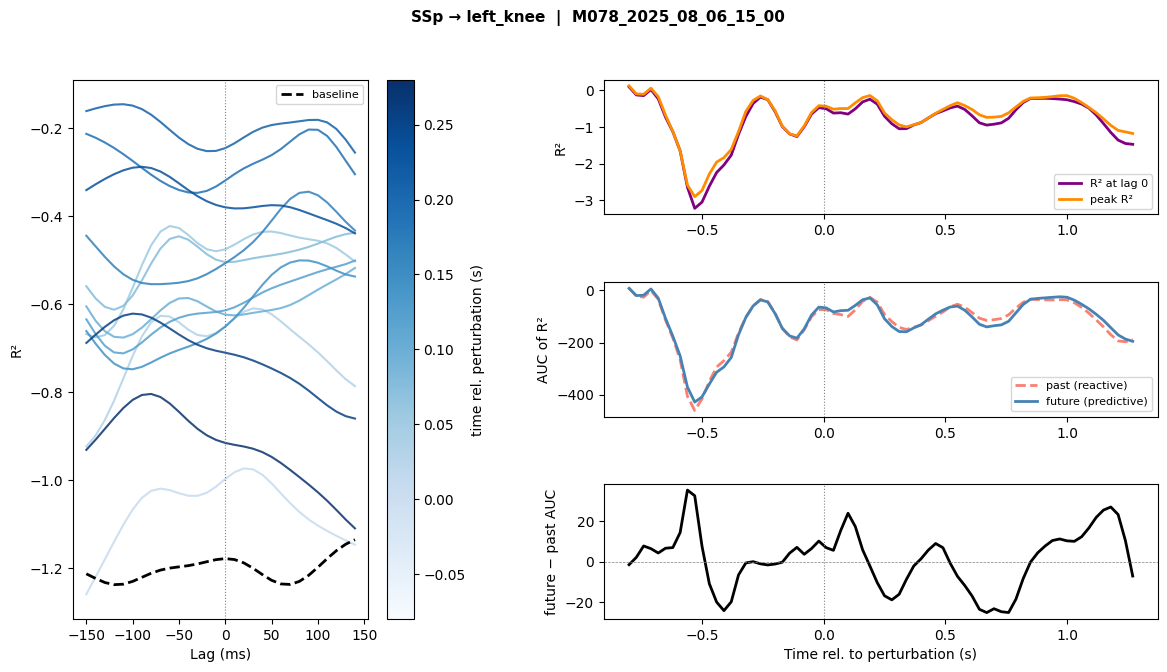

left_knee             peak diff=-25.029 at t=0.67s


/tmp/ipykernel_1318930/4260965959.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


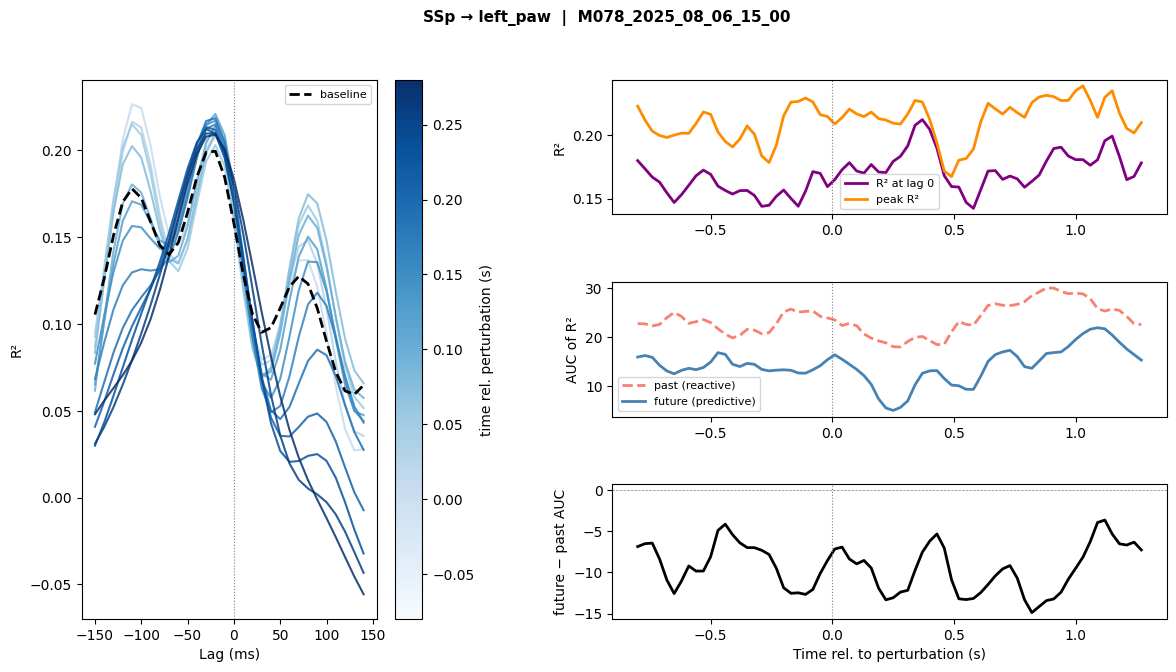

left_paw              peak diff=-14.867 at t=0.82s


/tmp/ipykernel_1318930/4260965959.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


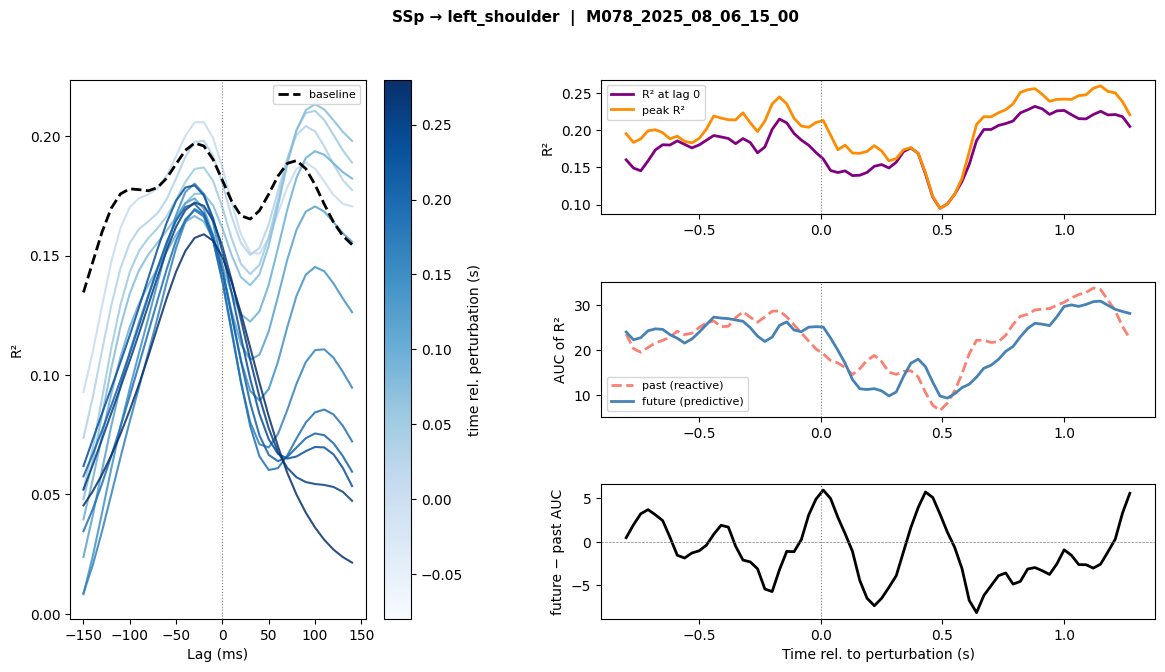

left_shoulder         peak diff=-8.166 at t=0.64s


/tmp/ipykernel_1318930/4260965959.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


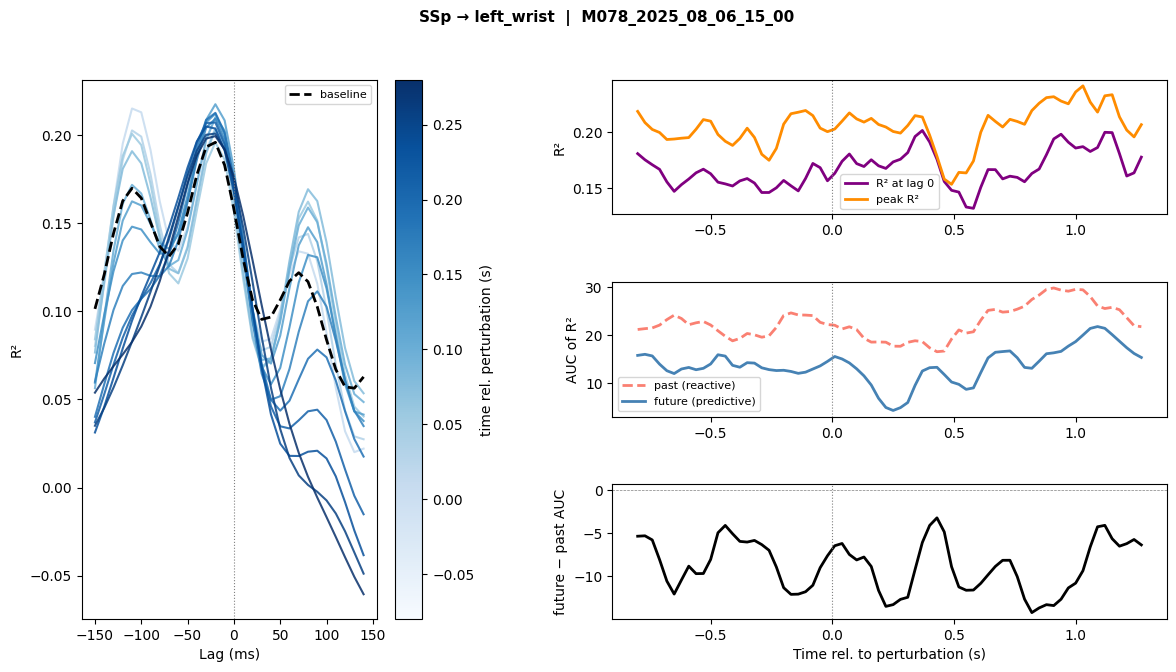

left_wrist            peak diff=-14.225 at t=0.82s


/tmp/ipykernel_1318930/4260965959.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


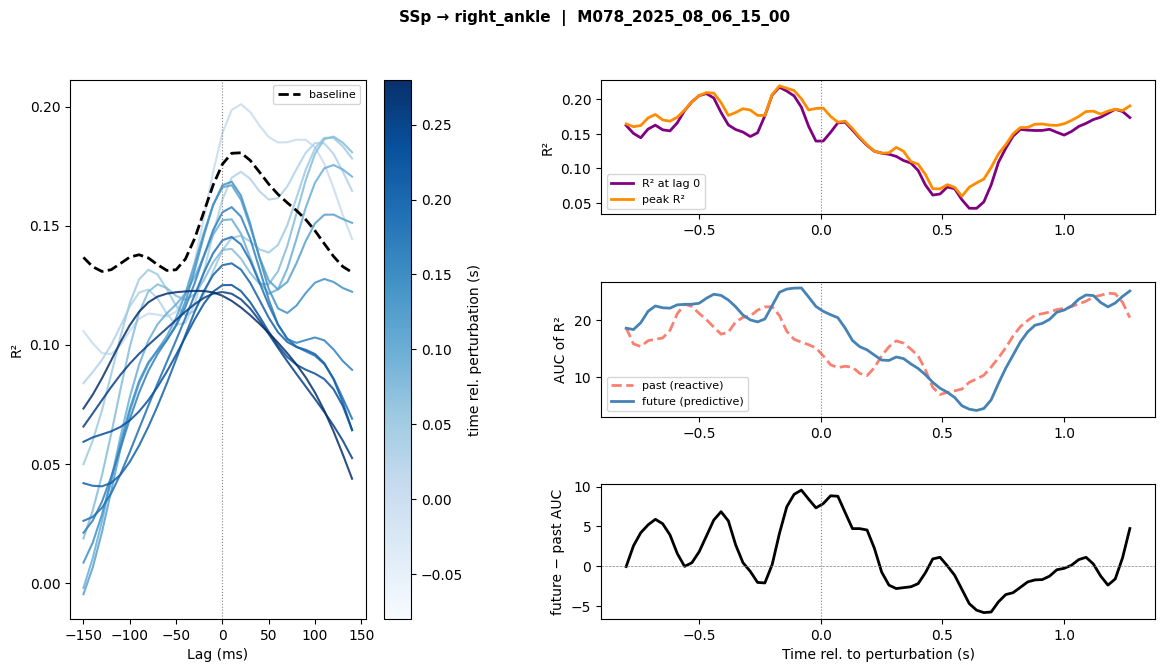

right_ankle           peak diff=-5.864 at t=0.67s


/tmp/ipykernel_1318930/4260965959.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


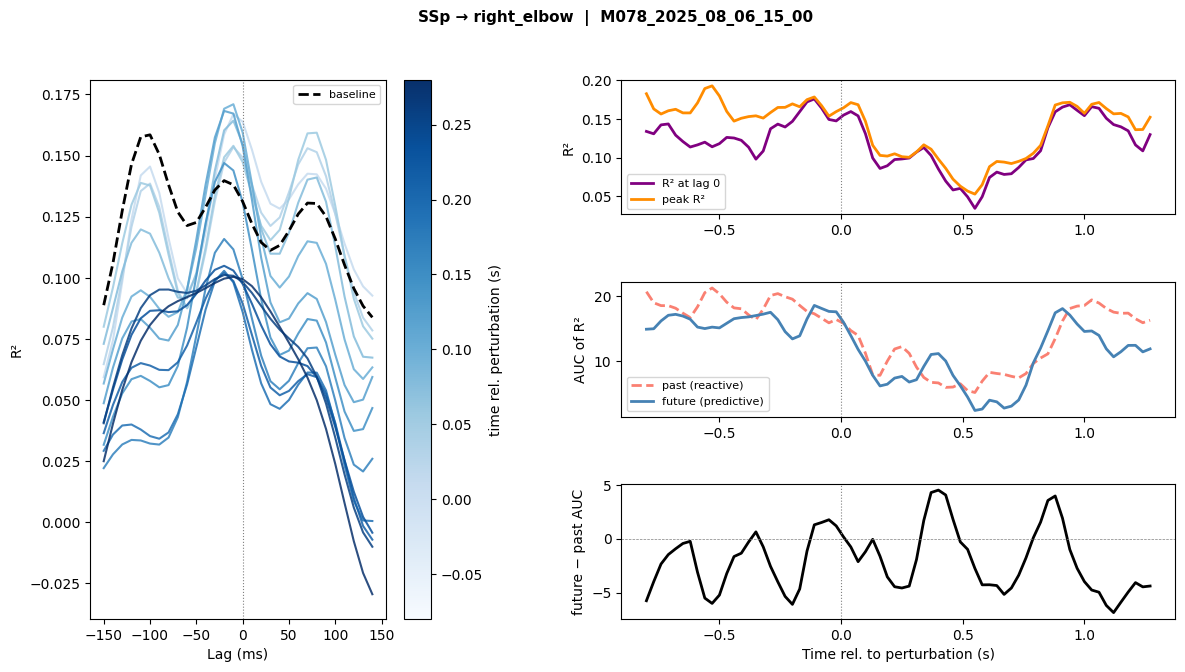

right_elbow           peak diff=-6.861 at t=1.12s


/tmp/ipykernel_1318930/4260965959.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


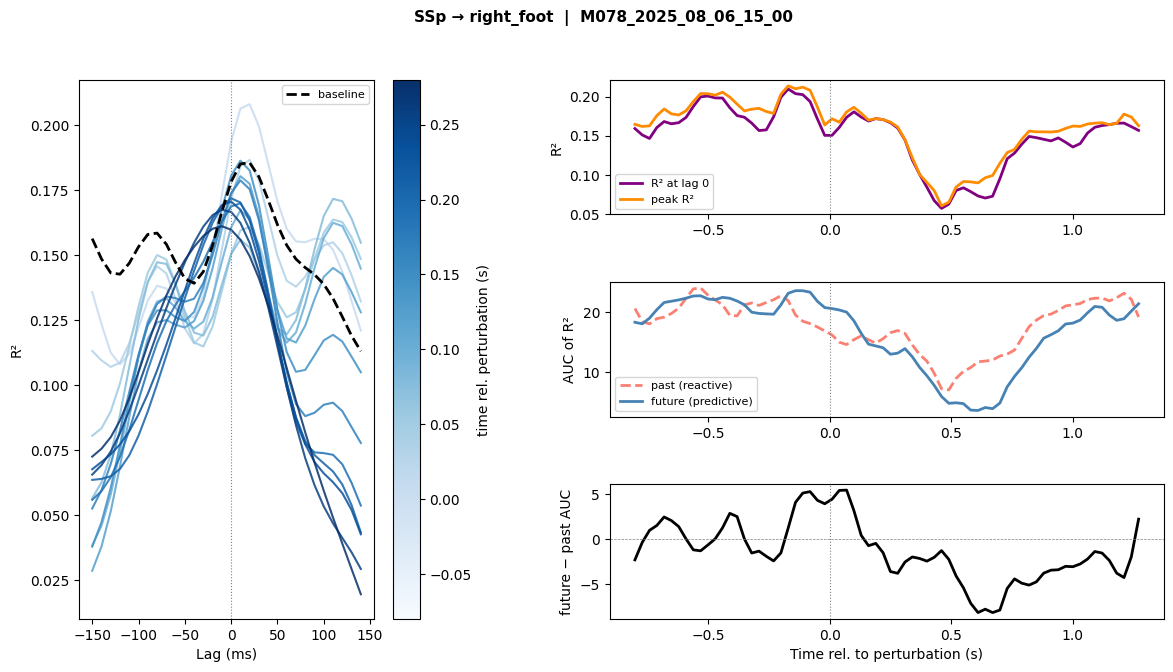

right_foot            peak diff=-8.163 at t=0.67s


/tmp/ipykernel_1318930/4260965959.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


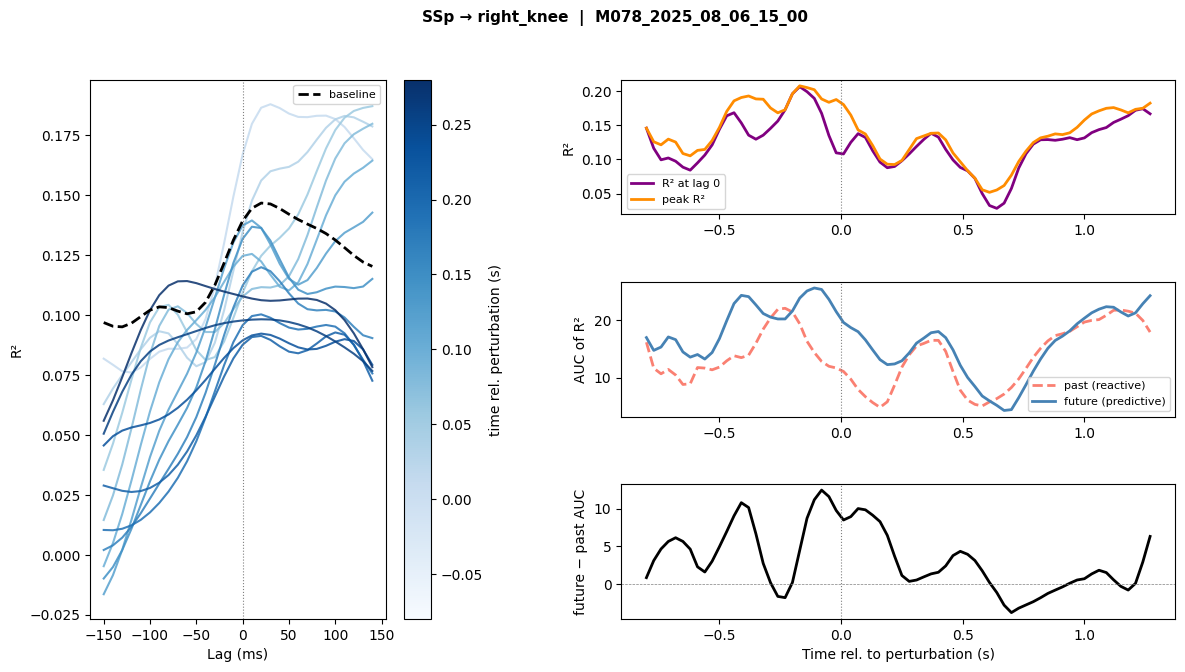

right_knee            peak diff=-3.831 at t=0.70s


/tmp/ipykernel_1318930/4260965959.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


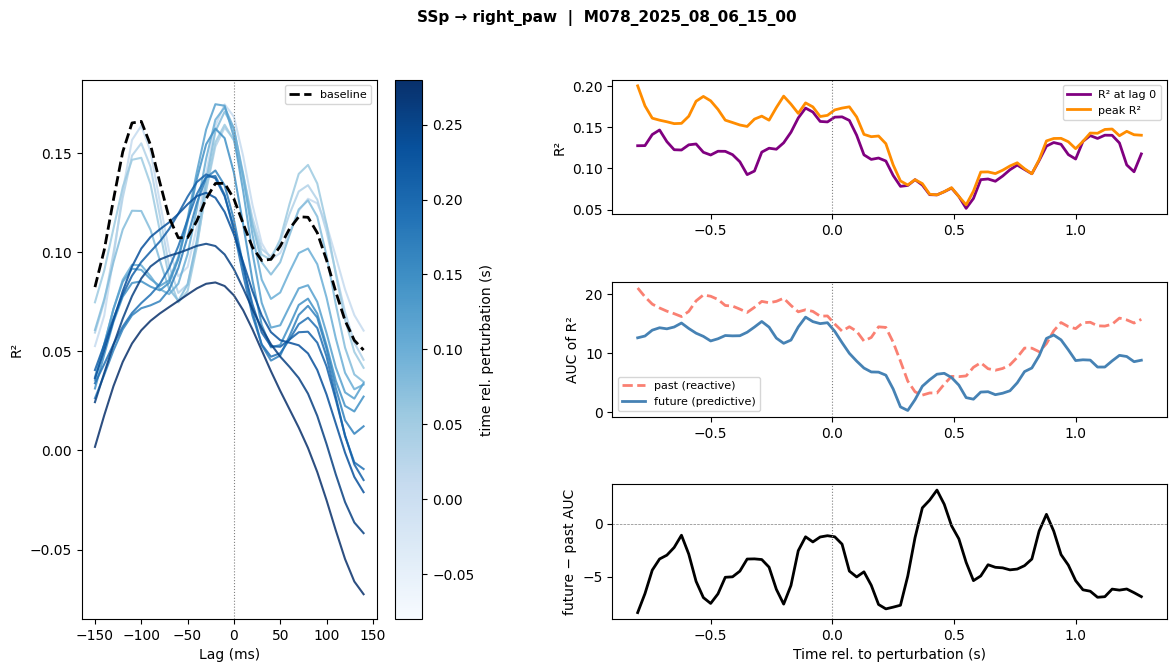

right_paw             peak diff=-8.412 at t=-0.80s


/tmp/ipykernel_1318930/4260965959.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


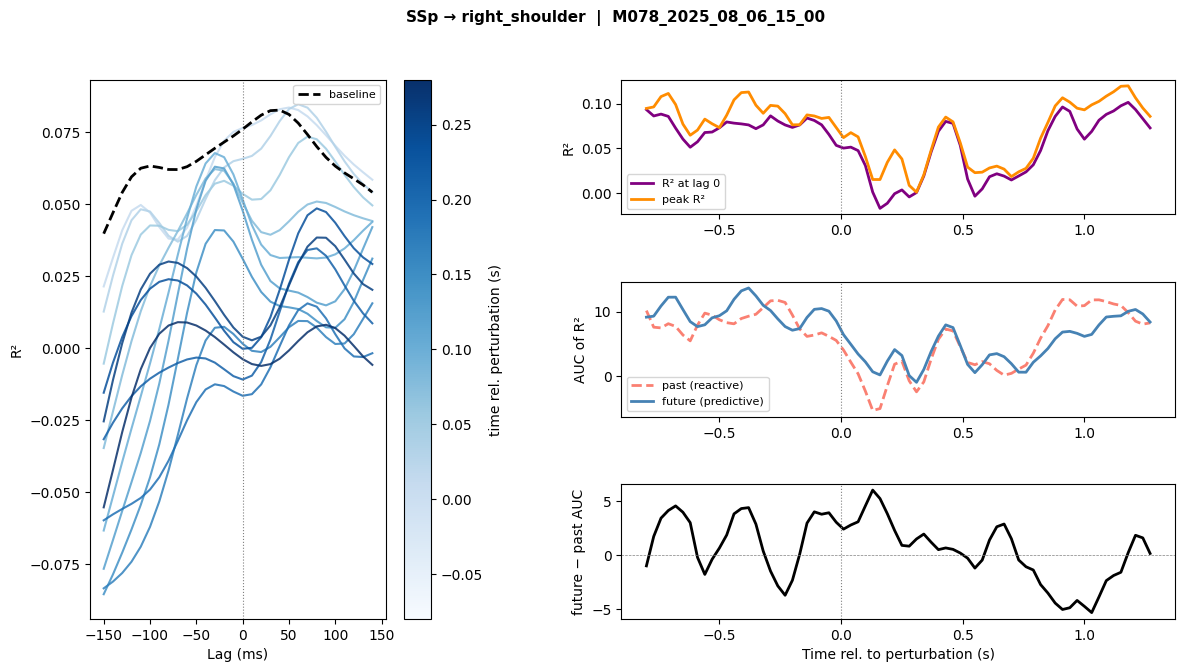

right_shoulder        peak diff=-5.355 at t=1.03s


/tmp/ipykernel_1318930/4260965959.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


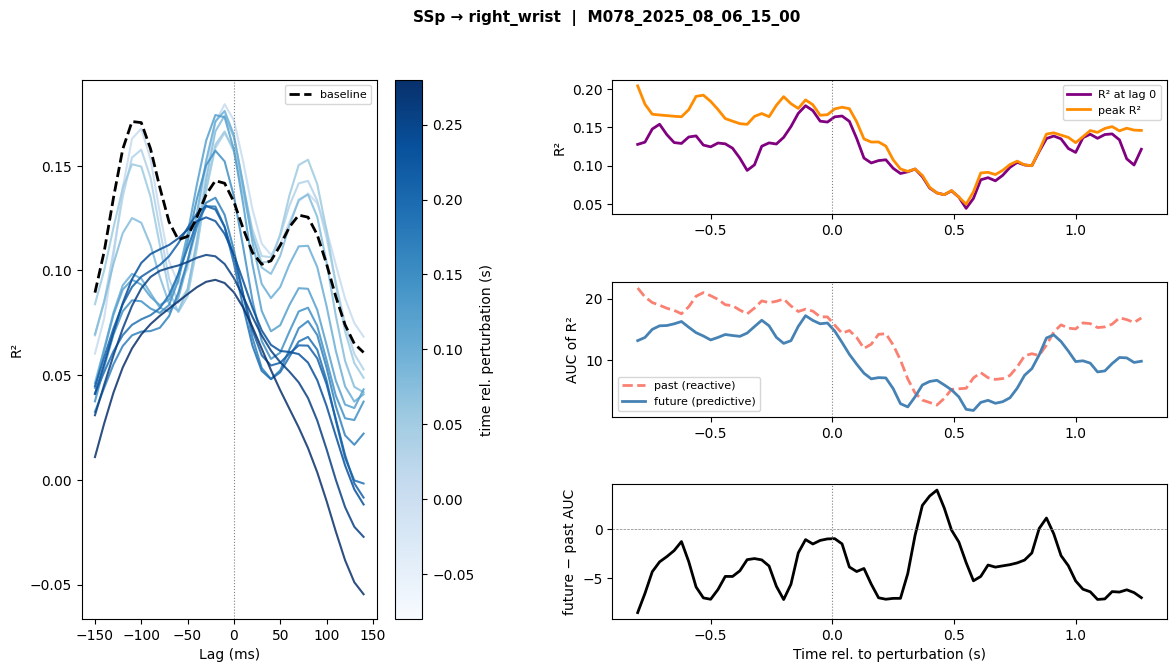

right_wrist           peak diff=-8.582 at t=-0.80s


/tmp/ipykernel_1318930/4260965959.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


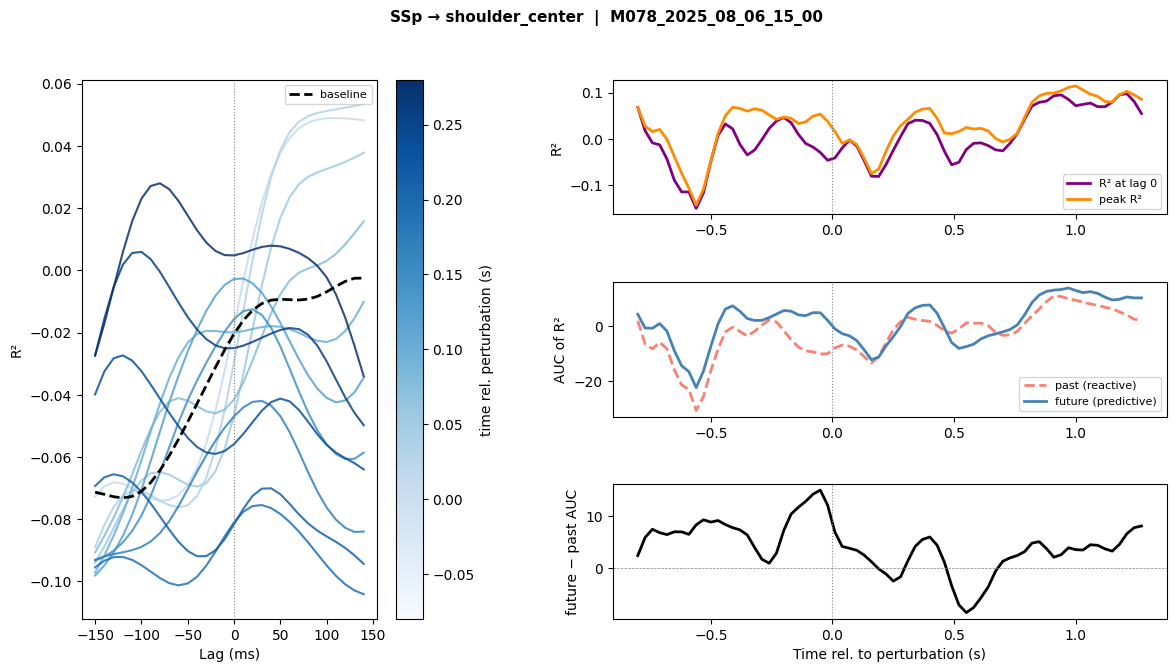

shoulder_center       peak diff=-8.583 at t=0.55s


/tmp/ipykernel_1318930/4260965959.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


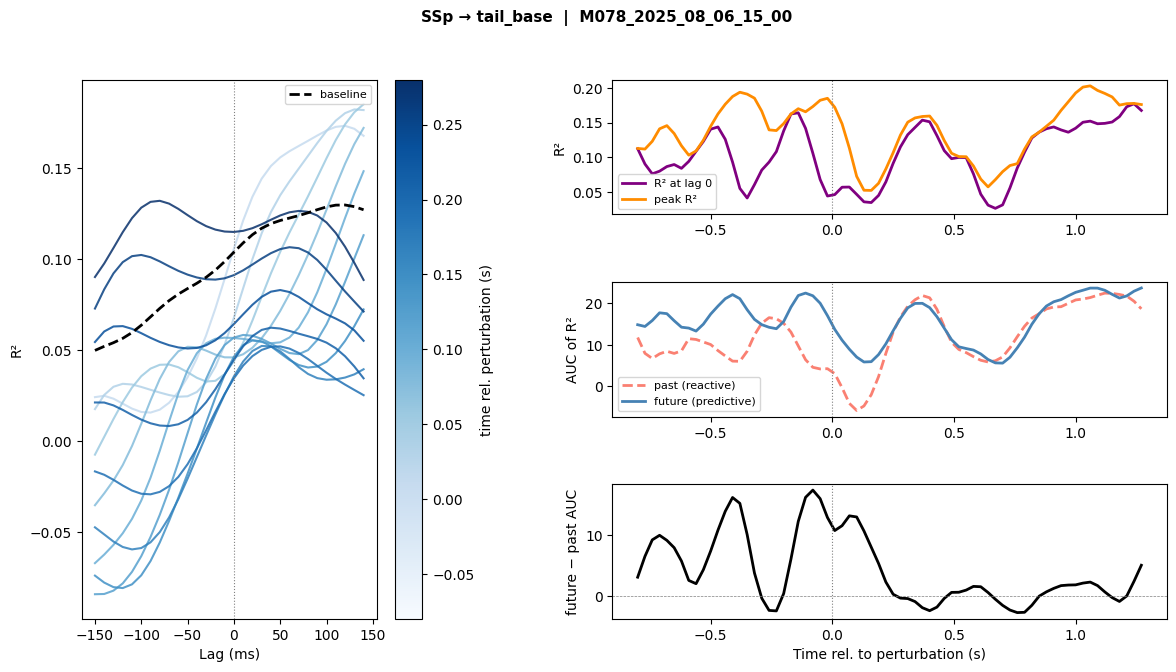

tail_base             peak diff=-2.690 at t=0.76s


/tmp/ipykernel_1318930/4260965959.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


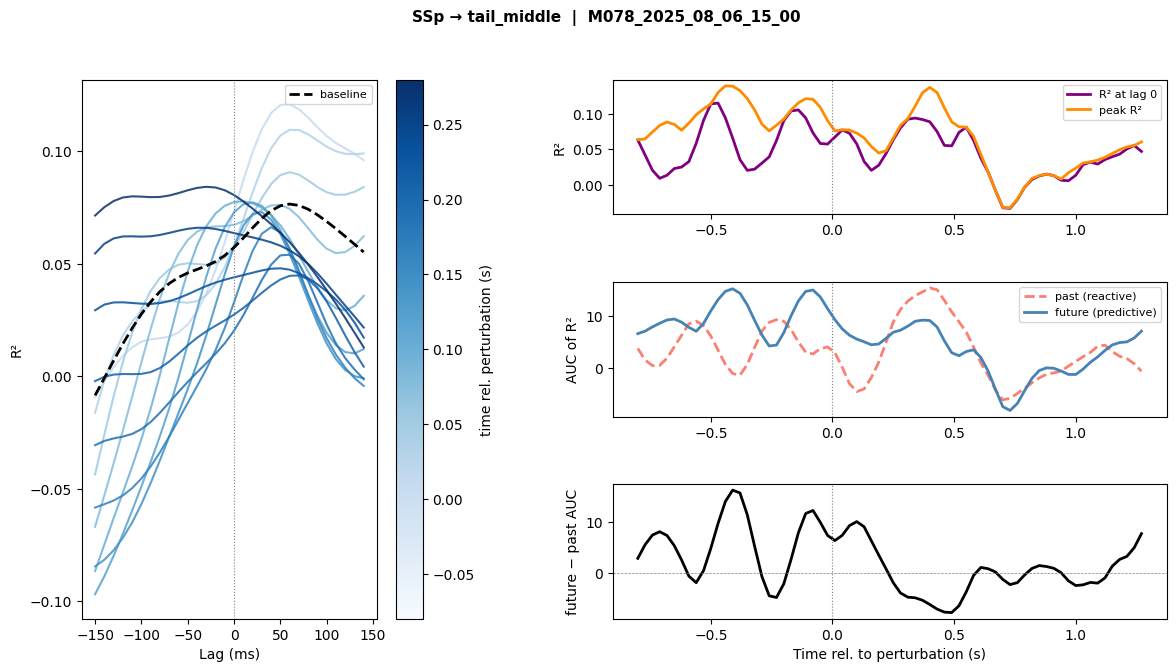

tail_middle           peak diff=-7.828 at t=0.49s


/tmp/ipykernel_1318930/4260965959.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


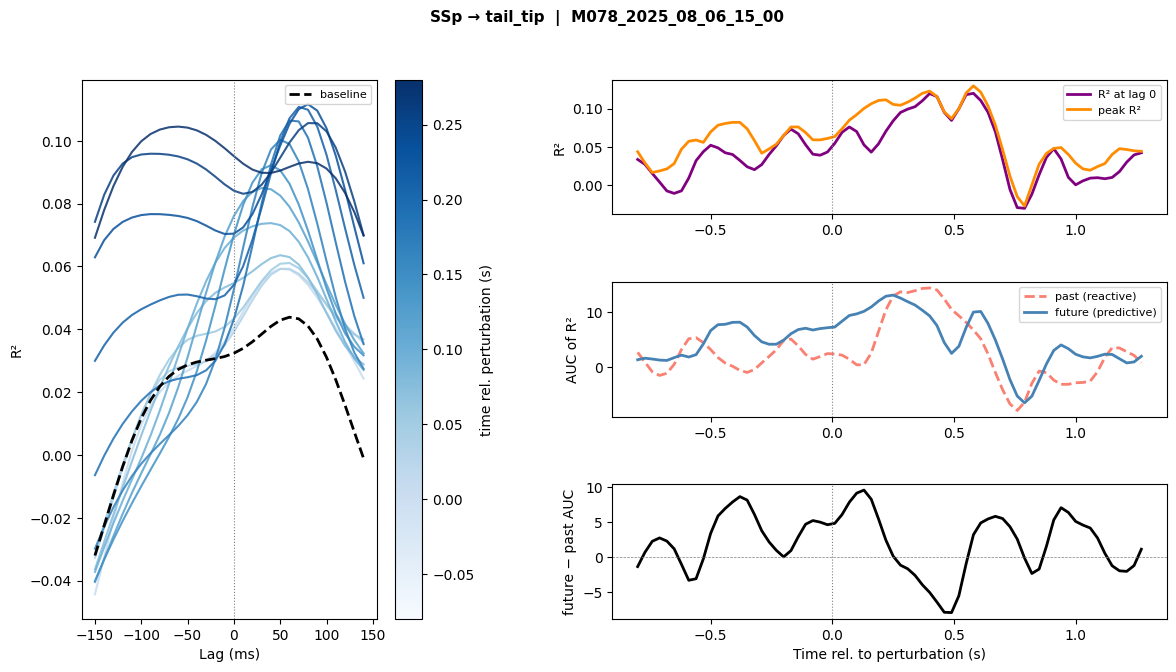

tail_tip              peak diff=-7.905 at t=0.49s


In [17]:
# ── Single-session multiplot ── change SESSION to explore ────────────────────
SESSION = 'M078_2025_08_06_15_00'

data    = all_data[SESSION]
lags_ms = all_lags[SESSION]
lag_mask, lags_masked, past_mask, future_mask = _make_masks(lags_ms)
lag0_idx = np.argmin(np.abs(lags_masked))
print(f'Session: {SESSION}  lags: {lags_masked[0]:.0f}→{lags_masked[-1]:.0f} ms  lag0={lags_masked[lag0_idx]:.1f} ms')

for kp in KEYPOINTS:
    res   = data[kp]
    t_all = np.array(sorted(res.keys()))

    bl_tmask = (t_all >= BASELINE_S[0]) & (t_all < BASELINE_S[1])
    bl_curve = np.array([res[ti].mean(-1)[lag_mask] for ti in t_all[bl_tmask]]).mean(0)

    ap, af, r2_0, r2_peak = [], [], [], []
    for ti in t_all:
        curve = res[ti].mean(-1)[lag_mask]
        ap.append(np.trapz(curve[past_mask],   lags_masked[past_mask]))
        af.append(np.trapz(curve[future_mask], lags_masked[future_mask]))
        r2_0.append(curve[lag0_idx])
        r2_peak.append(curve.max())
    ap, af, r2_0, r2_peak = np.array(ap), np.array(af), np.array(r2_0), np.array(r2_peak)

    sp_tmask = (t_all >= SPAGHETTI_S[0]) & (t_all <= SPAGHETTI_S[1])
    sp_t     = t_all[sp_tmask]
    sp_cols  = plt.cm.Blues(np.linspace(0.25, 1.0, len(sp_t)))

    fig = plt.figure(figsize=(14, 7))
    gs  = fig.add_gridspec(3, 2, width_ratios=[1, 1.5], hspace=0.5, wspace=0.35)
    ax_sp  = fig.add_subplot(gs[:, 0])
    ax_r2  = fig.add_subplot(gs[0, 1])
    ax_auc = fig.add_subplot(gs[1, 1])
    ax_dif = fig.add_subplot(gs[2, 1])

    ax_sp.plot(lags_masked, bl_curve, 'k--', lw=2, label='baseline', zorder=10)
    for ti, col in zip(sp_t, sp_cols):
        ax_sp.plot(lags_masked, res[ti].mean(-1)[lag_mask], color=col, alpha=0.85)
    sm = mpl.cm.ScalarMappable(cmap=plt.cm.Blues,
                                norm=mpl.colors.Normalize(vmin=sp_t[0], vmax=sp_t[-1]))
    sm.set_array([])
    fig.colorbar(sm, ax=ax_sp, label='time rel. perturbation (s)')
    ax_sp.axvline(0, color='gray', lw=0.8, ls=':')
    ax_sp.set_xlabel('Lag (ms)');  ax_sp.set_ylabel('R²')
    ax_sp.legend(fontsize=8)

    ax_r2.plot(t_all, r2_0,    color='purple', lw=2, label='R² at lag 0')
    ax_r2.plot(t_all, r2_peak, color='darkorange', lw=2, label='peak R²')
    ax_r2.axvline(0, color='gray', lw=0.8, ls=':')
    ax_r2.set_ylabel('R²')
    ax_r2.legend(fontsize=8)

    ax_auc.plot(t_all, ap, '--', color='salmon',    lw=2, label='past (reactive)')
    ax_auc.plot(t_all, af, '-',  color='steelblue', lw=2, label='future (predictive)')
    ax_auc.axvline(0, color='gray', lw=0.8, ls=':')
    ax_auc.set_ylabel('AUC of R²')
    ax_auc.legend(fontsize=8)

    diff = af - ap
    ax_dif.plot(t_all, diff, 'k', lw=2)
    ax_dif.axvline(0, color='gray', lw=0.8, ls=':')
    ax_dif.axhline(0, color='gray', lw=0.5, ls='--')
    ax_dif.set_xlabel('Time rel. to perturbation (s)')
    ax_dif.set_ylabel('future − past AUC')

    plt.suptitle(f'{AREA} → {kp}  |  {SESSION}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

    peak_idx = np.argmin(diff)
    print(f'{kp:20s}  peak diff={diff[peak_idx]:.3f} at t={t_all[peak_idx]:.2f}s')

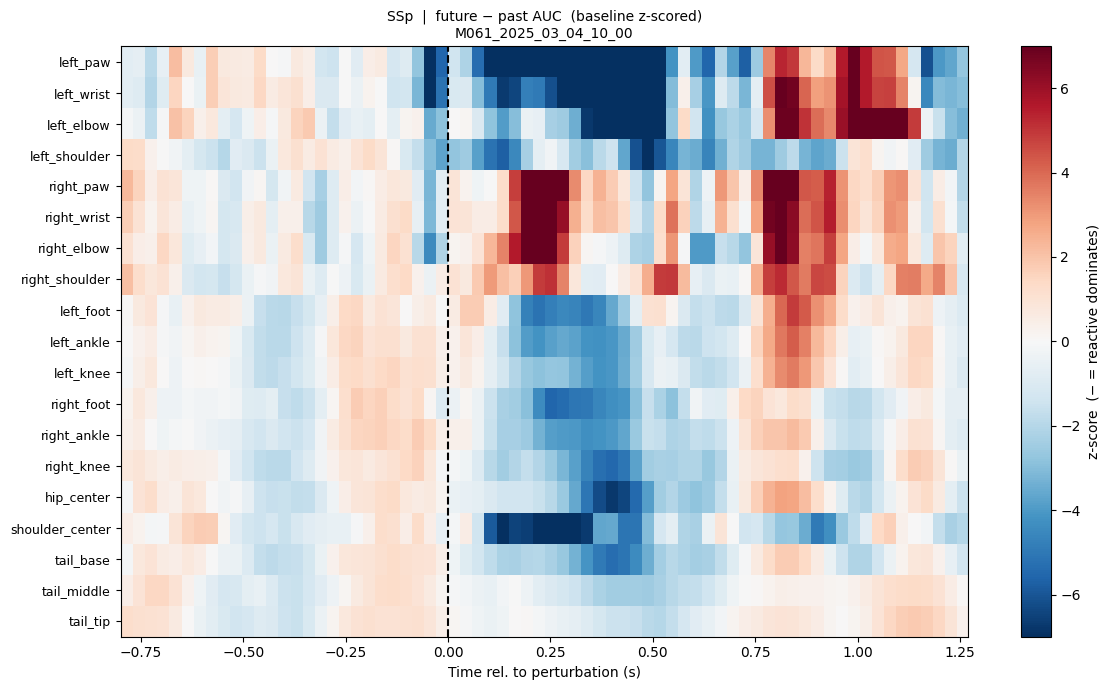

Session: M061_2025_03_04_10_00
Keypoints in display order  (min z-score post-perturbation):
  left_paw              min z = -27.69
  left_wrist            min z = -22.15
  left_elbow            min z = -16.94
  left_shoulder         min z = -7.50
  right_paw             min z = -2.76
  right_wrist           min z = -2.02
  right_elbow           min z = -2.30
  right_shoulder        min z = -0.77
  left_foot             min z = -5.18
  left_ankle            min z = -4.24
  left_knee             min z = -4.16
  right_foot            min z = -5.56
  right_ankle           min z = -4.28
  right_knee            min z = -5.50
  hip_center            min z = -6.74
  shoulder_center       min z = -9.19
  tail_base             min z = -5.33
  tail_middle           min z = -2.47
  tail_tip              min z = -2.01


In [73]:
# ── Heatmap: baseline z-scored future − past AUC, all keypoints ──────────────
# Uses SESSION defined in the single-session cell above
data    = all_data[SESSION]
lags_ms = all_lags[SESSION]
lag_mask, lags_masked, past_mask, future_mask = _make_masks(lags_ms)

heatmap_dict = {}
t_ref = None

for kp in KEYPOINTS:
    res   = data[kp]
    t_all = np.array(sorted(res.keys()))
    if t_ref is None:
        t_ref = t_all

    ap, af = [], []
    for ti in t_all:
        curve = res[ti].mean(-1)[lag_mask]
        ap.append(np.trapz(curve[past_mask],   lags_masked[past_mask]))
        af.append(np.trapz(curve[future_mask], lags_masked[future_mask]))
    diff = np.array(af) - np.array(ap)

    bl_mask = (t_ref >= BASELINE_S[0]) & (t_ref < BASELINE_S[1])
    bl_mu   = diff[bl_mask].mean()
    bl_std  = diff[bl_mask].std()
    heatmap_dict[kp] = (diff - bl_mu) / (bl_std + 1e-12)

# ── Body-part ordering: distal → proximal within each limb group ─────────────
KP_ORDER = [
    'left_paw',  'left_wrist',  'left_elbow',  'left_shoulder',
    'right_paw', 'right_wrist', 'right_elbow', 'right_shoulder',
    'left_foot',  'left_ankle',  'left_knee',
    'right_foot', 'right_ankle', 'right_knee',
    'hip_center', 'shoulder_center', 'tail_base', 'tail_middle', 'tail_tip',
]
KP_ORDER = [kp for kp in KP_ORDER if kp in heatmap_dict]
KP_ORDER += [kp for kp in KEYPOINTS if kp not in KP_ORDER]

heatmap = np.array([heatmap_dict[kp] for kp in KP_ORDER])
vmax    = np.percentile(np.abs(heatmap), 99)

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(heatmap, aspect='auto', cmap='RdBu_r',
               vmin=-7, vmax=7,
               extent=[t_ref[0], t_ref[-1], len(KP_ORDER) - 0.5, -0.5])
ax.set_yticks(range(len(KP_ORDER)))
ax.set_yticklabels(KP_ORDER, fontsize=9)
ax.axvline(0, color='k', lw=1.5, ls='--')
ax.set_xlabel('Time rel. to perturbation (s)')
ax.set_title(f'{AREA}  |  future − past AUC  (baseline z-scored)\n{SESSION}', fontsize=10)
fig.colorbar(im, ax=ax, label='z-score  (− = reactive dominates)')
plt.tight_layout()
plt.show()

post_mask = (t_ref >= 0) & (t_ref <= 0.6)
print(f'Session: {SESSION}')
print('Keypoints in display order  (min z-score post-perturbation):')
for kp in KP_ORDER:
    print(f'  {kp:20s}  min z = {heatmap_dict[kp][post_mask].min():.2f}')

Areas : ['CP', 'MOp', 'SSp', 'VAL']
Sessions (1):
  M078_2025_08_06_15_00


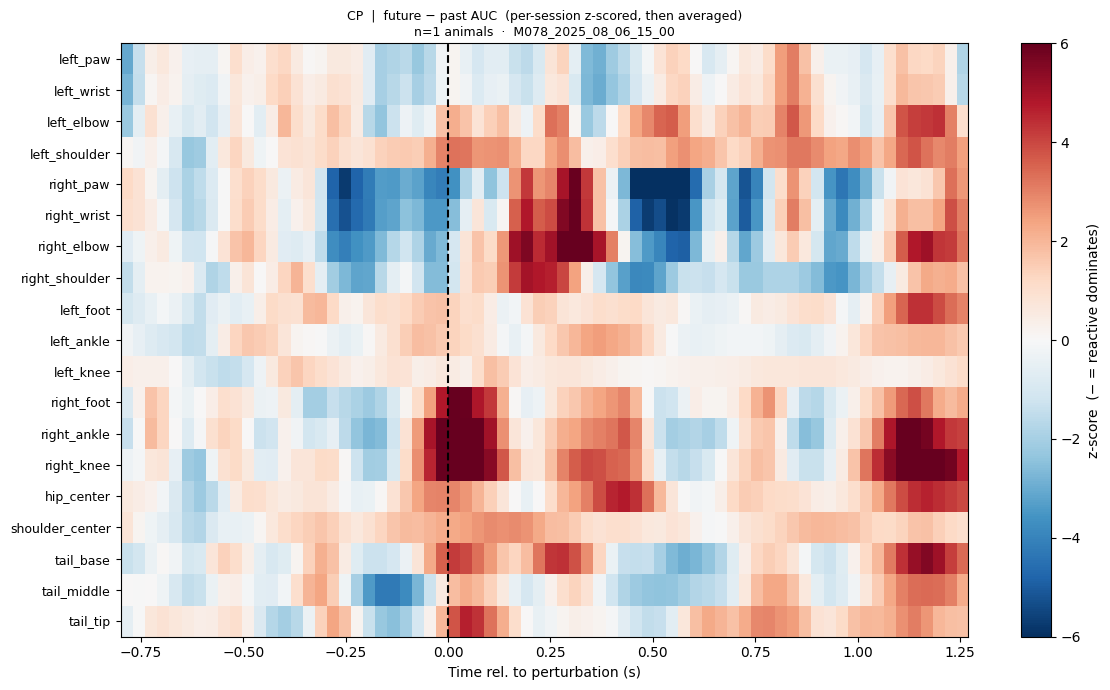

CP: 1 sessions, 1 animals


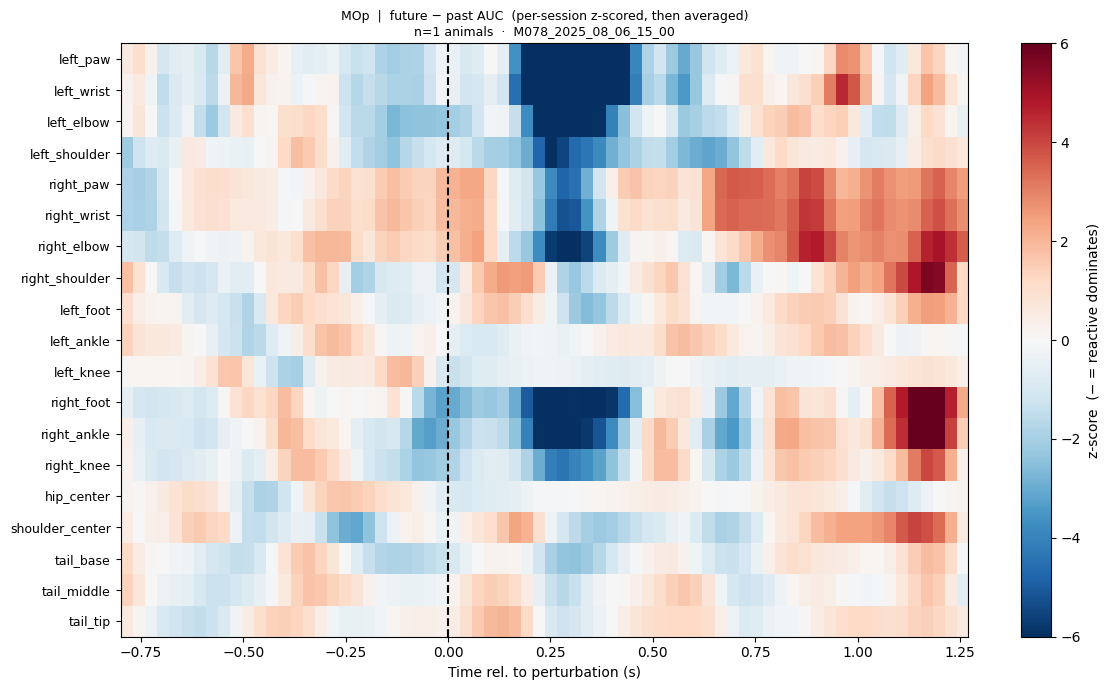

MOp: 1 sessions, 1 animals


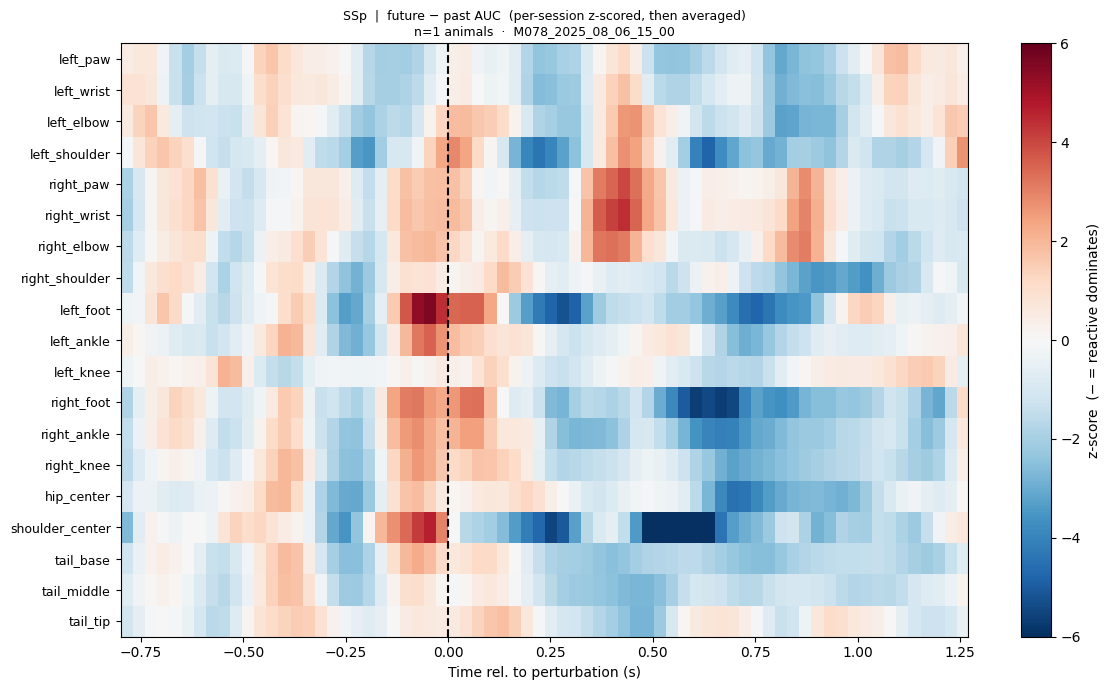

SSp: 1 sessions, 1 animals


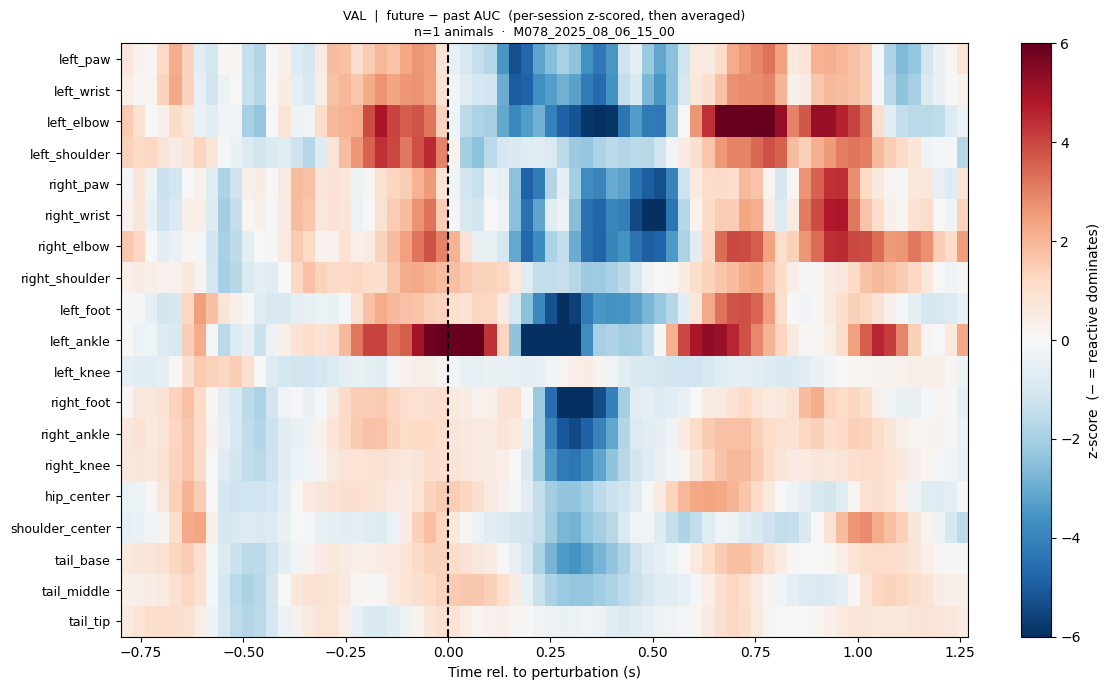

VAL: 1 sessions, 1 animals


In [21]:
# ── Heatmap for all sessions × all areas ─────────────────────────────────────
# !! Edit this list to keep only the sessions you trust !!
SESSIONS_ALL = [
    # 'M061_2025_03_04_10_00',
    # 'M061_2025_03_05_14_00',
    # 'M061_2025_03_06_14_00',
    # 'M062_2025_03_20_14_00',
    # 'M062_2025_03_21_14_00',
    # 'M063_2025_03_13_14_00',
    # 'M063_2025_03_14_15_30',
    'M078_2025_08_06_15_00',
    # 'M086_2025_12_10_15_00',
]

# !! Per-session area exclusions — add entries as needed !!
# Format: 'session': ['AREA1', 'AREA2', ...]
EXCLUDE_AREAS = {
    'M062_2025_03_20_14_00': ['VAL'],
    'M062_2025_03_21_14_00': ['VAL'],
    'M086_2025_12_10_15_00': ['VAL']
}

AREAS_ALL = sorted(set(
    f.stem.split('_')[2]
    for f in RESULTS_DIR.glob('lagged_dec_*.pkl')
))
print(f'Areas : {AREAS_ALL}')
print(f'Sessions ({len(SESSIONS_ALL)}):')
for s in SESSIONS_ALL:
    excl = EXCLUDE_AREAS.get(s, [])
    print(f'  {s}' + (f'  [exclude: {excl}]' if excl else ''))

KP_ORDER_ALL = [
    'left_paw',  'left_wrist',  'left_elbow',  'left_shoulder',
    'right_paw', 'right_wrist', 'right_elbow', 'right_shoulder',
    'left_foot',  'left_ankle',  'left_knee',
    'right_foot', 'right_ankle', 'right_knee',
    'hip_center', 'shoulder_center', 'tail_base', 'tail_middle', 'tail_tip',
]

def _load_session_for_area(area, session):
    pkl_path = RESULTS_DIR / f'lagged_dec_{area}_{session}.pkl'
    with open(pkl_path, 'rb') as fh:
        raw = pickle.load(fh)
    if '_meta' in raw:
        meta    = raw.pop('_meta')
        lags_ms = meta['lags_s'] * 1000
    else:
        n_lags  = next(iter(next(iter(raw.values())).values())).shape[0]
        lags_ms = np.linspace(-250, 250, n_lags)
    return raw, lags_ms

def _area_heatmap(area, sessions):
    zscored_per_animal = {}
    t_ref  = None
    loaded = []

    for sess in sessions:
        if area in EXCLUDE_AREAS.get(sess, []):
            print(f'  EXCL {area}/{sess}')
            continue
        try:
            data, lags_ms = _load_session_for_area(area, sess)
        except FileNotFoundError:
            print(f'  SKIP {area}/{sess} — not found')
            continue
        loaded.append(sess)
        ani = sess[:4]
        lag_mask, lags_masked, past_mask, future_mask = _make_masks(lags_ms)

        for kp in data:
            res   = data[kp]
            t_all = np.array(sorted(res.keys()))
            if t_ref is None:
                t_ref = t_all

            ap, af = [], []
            for ti in t_all:
                curve = res[ti].mean(-1)[lag_mask]
                ap.append(np.trapz(curve[past_mask],   lags_masked[past_mask]))
                af.append(np.trapz(curve[future_mask], lags_masked[future_mask]))
            diff = np.array(af) - np.array(ap)

            bl_mask = (t_ref >= BASELINE_S[0]) & (t_ref < BASELINE_S[1])
            bl_mu   = diff[bl_mask].mean()
            bl_std  = diff[bl_mask].std()
            z = (diff - bl_mu) / (bl_std + 1e-12)

            zscored_per_animal.setdefault(kp, {}).setdefault(ani, []).append(z)

    heatmap_dict = {}
    for kp, by_animal in zscored_per_animal.items():
        ani_means = [np.mean(v, axis=0) for v in by_animal.values()]
        heatmap_dict[kp] = np.mean(ani_means, axis=0)

    kp_order = [kp for kp in KP_ORDER_ALL if kp in heatmap_dict]
    kp_order += [kp for kp in heatmap_dict if kp not in kp_order]
    heatmap  = np.array([heatmap_dict[kp] for kp in kp_order])
    n_ani    = len(set(s[:4] for s in loaded))
    return t_ref, heatmap, kp_order, loaded, n_ani

# ── Plot ──────────────────────────────────────────────────────────────────────
for area in AREAS_ALL:
    t_ref, heatmap, kp_order, loaded, n_ani = _area_heatmap(area, SESSIONS_ALL)
    if heatmap.size == 0:
        print(f'SKIP {area} — no data')
        continue

    vmax         = np.percentile(np.abs(heatmap), 99)
    sessions_str = '  ·  '.join(loaded)

    fig, ax = plt.subplots(figsize=(12, 7))
    im = ax.imshow(heatmap, aspect='auto', cmap='RdBu_r', vmin=-6, vmax=6,
                   extent=[t_ref[0], t_ref[-1], len(kp_order) - 0.5, -0.5])
    ax.set_yticks(range(len(kp_order)))
    ax.set_yticklabels(kp_order, fontsize=9)
    ax.axvline(0, color='k', lw=1.5, ls='--')
    ax.set_xlabel('Time rel. to perturbation (s)')
    ax.set_title(f'{area}  |  future − past AUC  (per-session z-scored, then averaged)\n'
                 f'n={n_ani} animals  ·  {sessions_str}', fontsize=9)
    fig.colorbar(im, ax=ax, label='z-score  (− = reactive dominates)')
    plt.tight_layout()
    plt.show()
    print(f'{area}: {len(loaded)} sessions, {n_ani} animals')

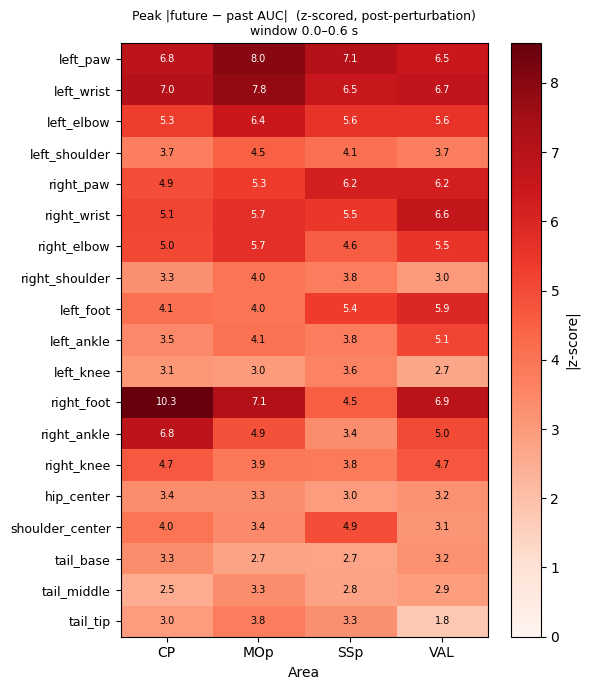

Post window: 0.0–0.6 s
KP                        CP     MOp     SSp     VAL
left_paw                6.81    7.99    7.06    6.45
left_wrist              7.05    7.77    6.51    6.69
left_elbow              5.31    6.44    5.58    5.58
left_shoulder           3.69    4.48    4.08    3.71
right_paw               4.89    5.34    6.19    6.22
right_wrist             5.10    5.72    5.47    6.65
right_elbow             5.04    5.71    4.57    5.55
right_shoulder          3.28    4.01    3.77    3.00
left_foot               4.09    3.96    5.35    5.92
left_ankle              3.47    4.06    3.76    5.14
left_knee               3.05    3.00    3.62    2.68
right_foot             10.32    7.13    4.52    6.90
right_ankle             6.81    4.85    3.37    5.02
right_knee              4.68    3.95    3.85    4.73
hip_center              3.35    3.33    2.97    3.23
shoulder_center         3.96    3.43    4.91    3.14
tail_base               3.33    2.75    2.74    3.20
tail_middle            

In [152]:
# ── Summary heatmap: peak future−past AUC (z-scored) × keypoint × area ───────
# For each session: z-score the diff curve to baseline, take peak abs value in post window
# Then average within animal → across animals
# Result: one scalar per (area, keypoint)

POST_WINDOW = (0.0, 0.6)   # s — window to search for the peak dip

summary = {}   # area → kp → scalar

for area in AREAS_ALL:
    peak_per_animal = {}   # kp → animal → list of scalars

    for sess in SESSIONS_ALL:
        if area in EXCLUDE_AREAS.get(sess, []):
            continue
        try:
            data, lags_ms = _load_session_for_area(area, sess)
        except FileNotFoundError:
            continue

        ani = sess[:4]
        lag_mask, lags_masked, past_mask, future_mask = _make_masks(lags_ms)
        t_ref_local = None

        for kp in data:
            res   = data[kp]
            t_all = np.array(sorted(res.keys()))
            if t_ref_local is None:
                t_ref_local = t_all

            ap, af = [], []
            for ti in t_all:
                curve = res[ti].mean(-1)[lag_mask]
                ap.append(np.trapz(curve[past_mask],   lags_masked[past_mask]))
                af.append(np.trapz(curve[future_mask], lags_masked[future_mask]))
            diff = np.array(af) - np.array(ap)

            bl_m   = (t_ref_local >= BASELINE_S[0]) & (t_ref_local < BASELINE_S[1])
            post_m = (t_ref_local >= POST_WINDOW[0]) & (t_ref_local <= POST_WINDOW[1])
            bl_mu, bl_std = diff[bl_m].mean(), diff[bl_m].std()
            z = (diff - bl_mu) / (bl_std + 1e-12)

            peak_per_animal.setdefault(kp, {}).setdefault(ani, []).append(np.abs(z[post_m]).max())

    summary[area] = {
        kp: np.mean([np.mean(v) for v in by_ani.values()])
        for kp, by_ani in peak_per_animal.items()
    }

# ── Build matrix: keypoints × areas ──────────────────────────────────────────
kp_order = [kp for kp in KP_ORDER_ALL if kp in next(iter(summary.values()))]
kp_order += [kp for kp in next(iter(summary.values())) if kp not in kp_order]

matrix = np.array([
    [summary[area].get(kp, np.nan) for area in AREAS_ALL]
    for kp in kp_order
])   # (n_kp, n_areas)

vmax = np.nanpercentile(matrix, 99)

fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(matrix, aspect='auto', cmap='Reds', vmin=0, vmax=vmax)
ax.set_xticks(range(len(AREAS_ALL)))
ax.set_xticklabels(AREAS_ALL, fontsize=10)
ax.set_yticks(range(len(kp_order)))
ax.set_yticklabels(kp_order, fontsize=9)
ax.set_xlabel('Area')
ax.set_title(f'Peak |future − past AUC|  (z-scored, post-perturbation)\n'
             f'window {POST_WINDOW[0]}–{POST_WINDOW[1]} s', fontsize=9)
fig.colorbar(im, ax=ax, label='|z-score|')

for i, kp in enumerate(kp_order):
    for j, area in enumerate(AREAS_ALL):
        val = matrix[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                    fontsize=7, color='white' if val > vmax * 0.6 else 'black')

plt.tight_layout()
plt.show()

print(f'Post window: {POST_WINDOW[0]}–{POST_WINDOW[1]} s')
print(f'{"KP":20s}  ' + '  '.join(f'{a:>6}' for a in AREAS_ALL))
for i, kp in enumerate(kp_order):
    vals = '  '.join(f'{matrix[i,j]:6.2f}' for j in range(len(AREAS_ALL)))
    print(f'{kp:20s}  {vals}')

# Manual inspection

In [22]:
SESSIONS_ALL = [
    'M061_2025_03_04_10_00',
    'M061_2025_03_05_14_00',
    'M061_2025_03_06_14_00',
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    # 'M063_2025_03_13_14_00',
    # 'M063_2025_03_14_15_30',
    'M078_2025_08_06_15_00',
    'M086_2025_12_10_15_00',
]

In [23]:
KP_ORDER[10]

'left_knee'

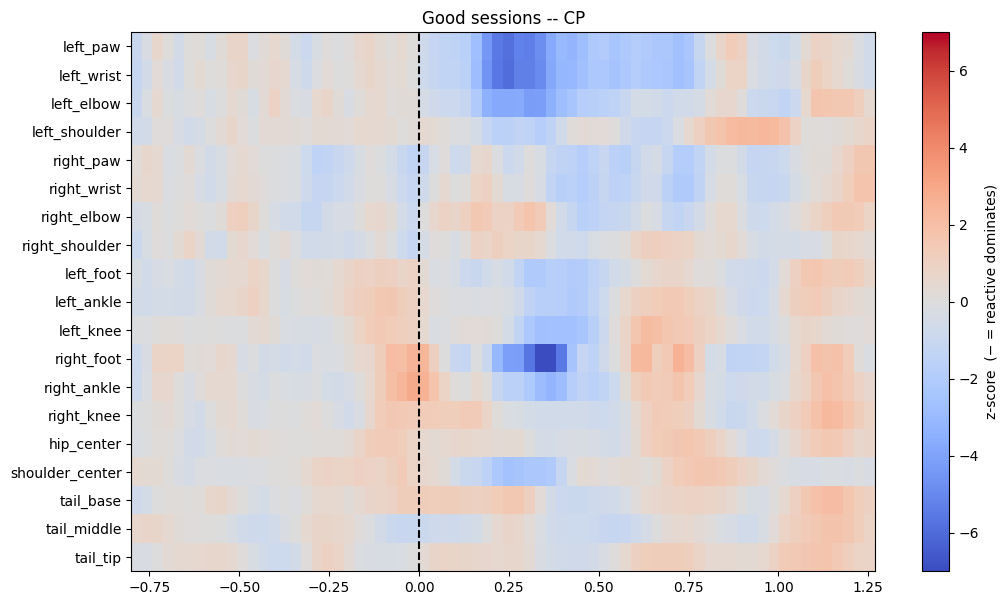

In [24]:
area = 'CP'
BASELINE_S = (-0.8, -.3)
bl_mask = (t_all >= BASELINE_S[0]) & (t_all < BASELINE_S[1])
KP_ORDER = [
    'left_paw',  'left_wrist',  'left_elbow',  'left_shoulder',
    'right_paw', 'right_wrist', 'right_elbow', 'right_shoulder',
    'left_foot',  'left_ankle',  'left_knee',
    'right_foot', 'right_ankle', 'right_knee',
    'hip_center', 'shoulder_center', 'tail_base', 'tail_middle', 'tail_tip',
]
heatmaps = []
for sess in SESSIONS_ALL:
    heatmap_dict = {}

    for kp in KP_ORDER:
        data, lags_ms = _load_session_for_area(area, sess)
        lag_mask, lags_masked, past_mask, future_mask = _make_masks(lags_ms)
        lag0_idx = np.argmin(np.abs(lags_masked))

        res   = data[kp]
        t_all = np.array(sorted(res.keys()))
        ap, af, r2_0 = [], [], []

        for ti in t_all:
            curve = res[ti].mean(-1)[lag_mask]
            ap.append(np.trapz(curve[past_mask],   lags_masked[past_mask]))
            af.append(np.trapz(curve[future_mask], lags_masked[future_mask]))
            r2_0.append(curve[lag0_idx])
        ap, af, r2_0 = np.array(ap), np.array(af), np.array(r2_0)
        diff = af - ap
        bl_z_diff = (diff - diff[bl_mask].mean()) / diff[bl_mask].std()

        heatmap_dict[kp] = bl_z_diff
    heatmap = np.array([heatmap_dict[kp] for kp in KP_ORDER])
    heatmaps.append(heatmap)

heatmaps = np.array(heatmaps)
# Weight each animal equally: average within animal first, then across animals
animal_ids = [sess.split('_')[0] for sess in SESSIONS_ALL]
unique_animals = dict.fromkeys(animal_ids)  # preserves insertion order
per_animal = [heatmaps[[i for i, a in enumerate(animal_ids) if a == animal]].mean(0)
              for animal in unique_animals]
heatmap_across_sess = np.mean(per_animal, axis=0)
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(heatmap_across_sess, aspect='auto', cmap='coolwarm',
               vmin=-7, vmax=7, 
               extent=[t_all[0], t_all[-1], len(KP_ORDER) - 0.5, -0.5]
               )
ax.set_yticks(range(len(KP_ORDER)))
ax.set_yticklabels(KP_ORDER)
ax.axvline(0, color='k', linestyle='dashed')
# ax.set_title(f"{SESSIONS_ALL} -- {area}")
ax.set_title(f"Good sessions -- {area}")
fig.colorbar(im, ax=ax, label='z-score  (− = reactive dominates)')


In [504]:
SESSIONS_ALL = [
    # 'M061_2025_03_04_10_00',
    # 'M061_2025_03_05_14_00',
    # 'M061_2025_03_06_14_00',
    # 'M062_2025_03_20_14_00',
    # 'M062_2025_03_21_14_00',
    # 'M063_2025_03_13_14_00',
    # 'M063_2025_03_14_15_30',
    # 'M078_2025_08_06_15_00',
    'M086_2025_12_10_15_00',
]

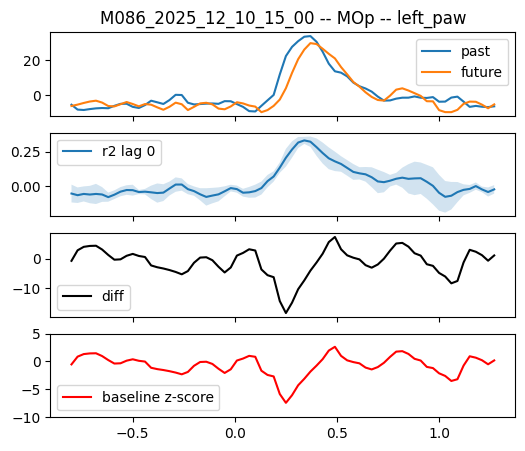

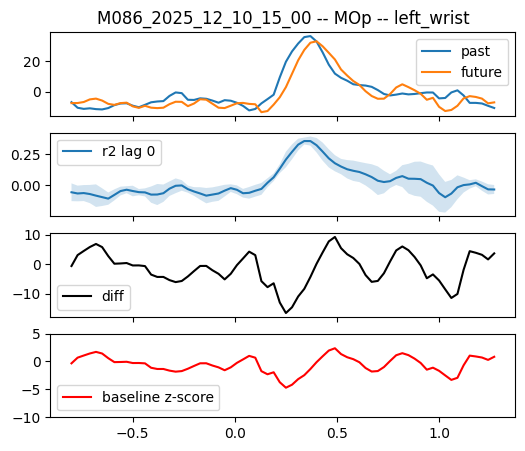

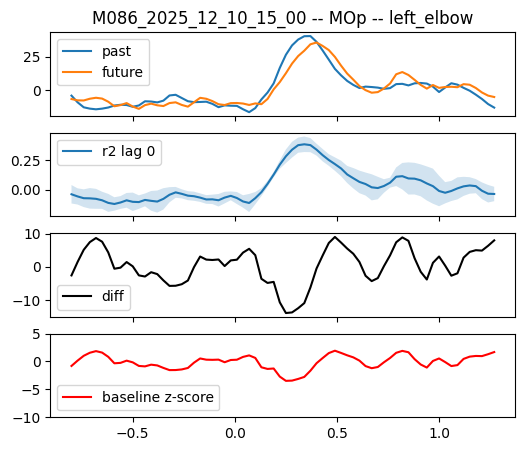

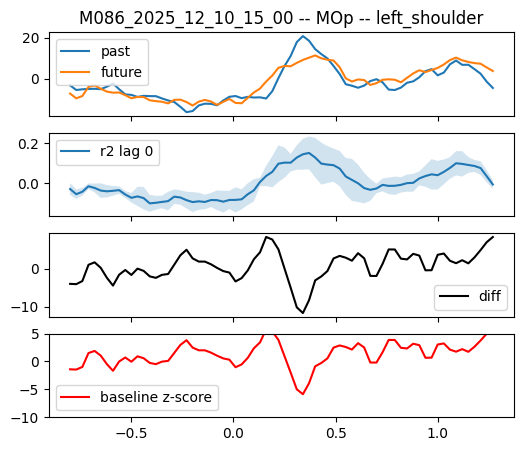

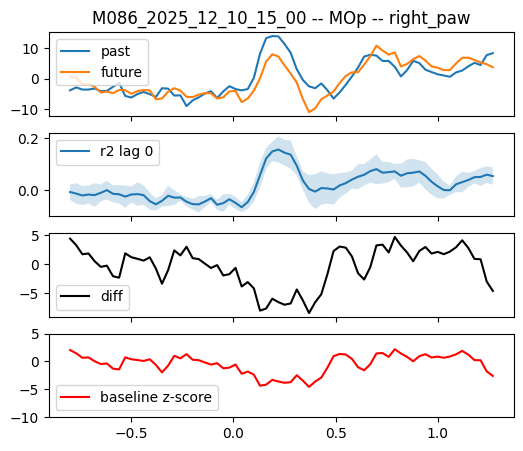

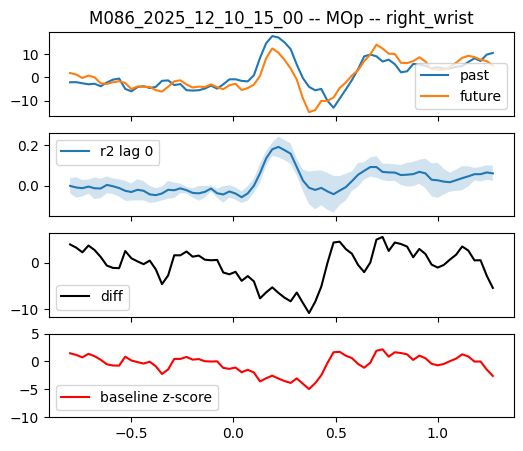

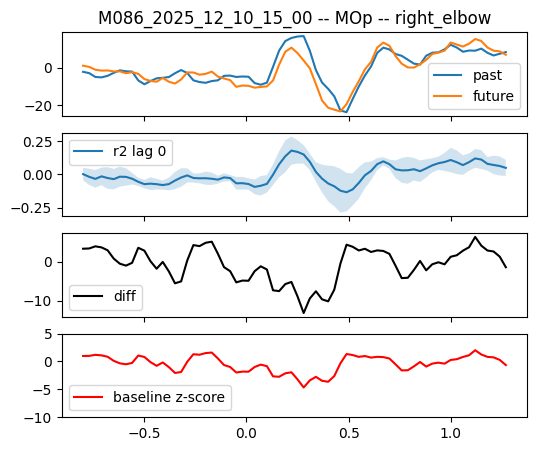

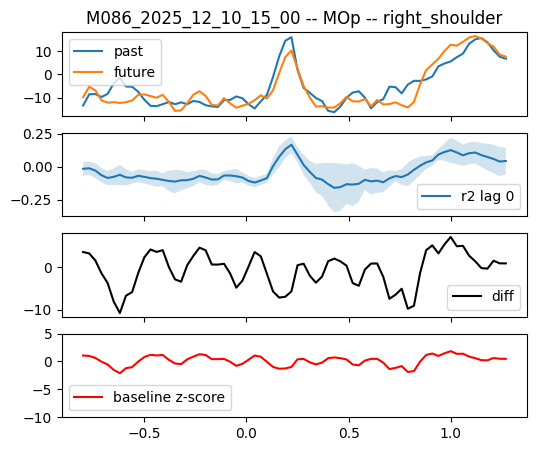

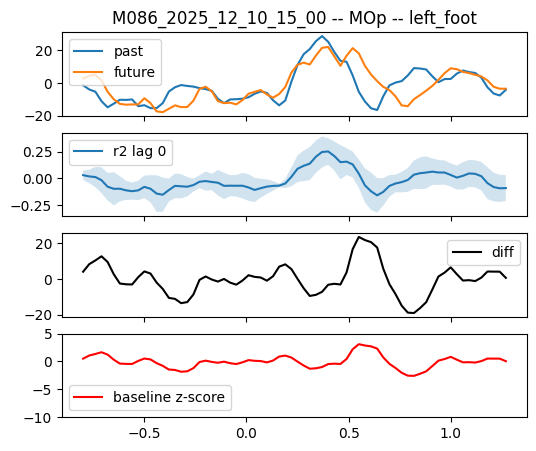

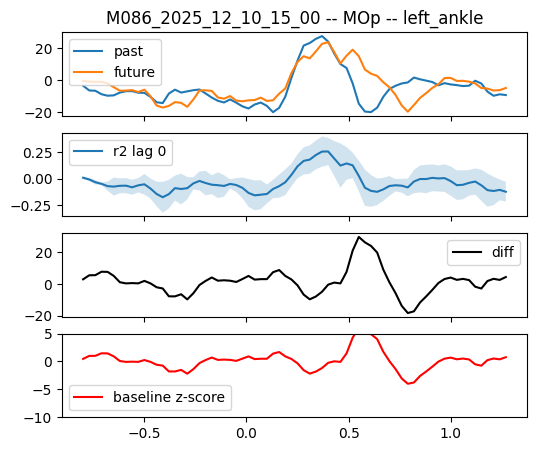

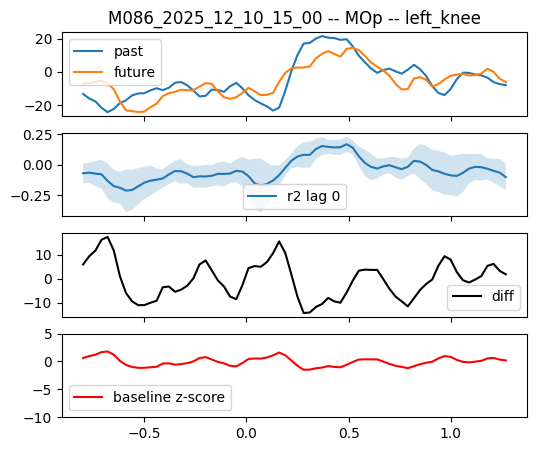

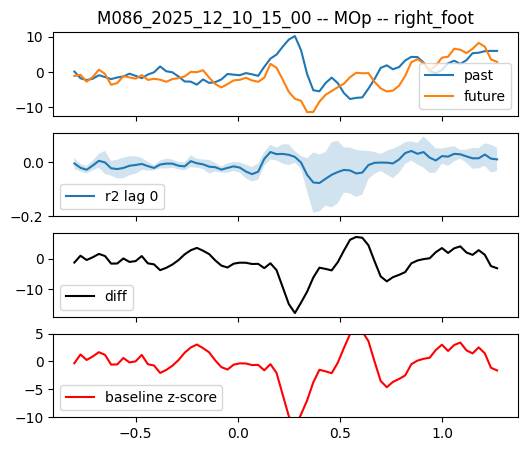

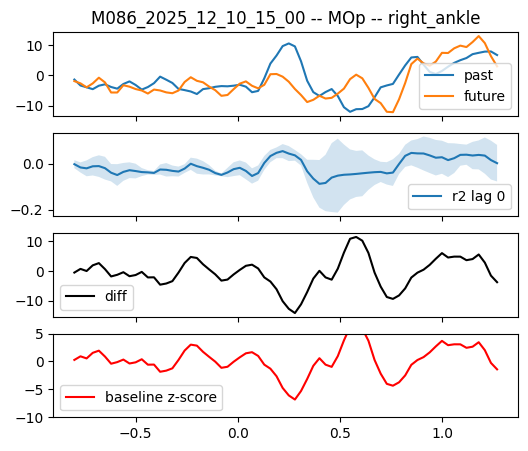

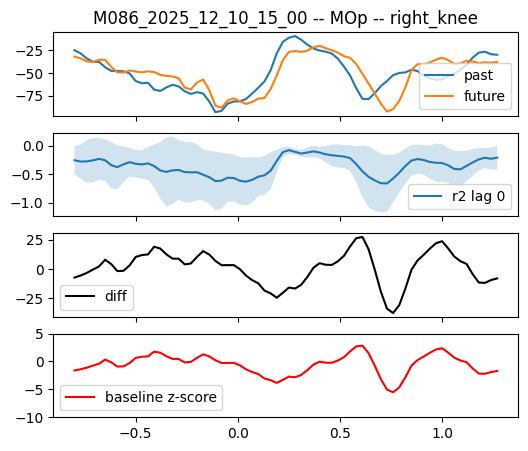

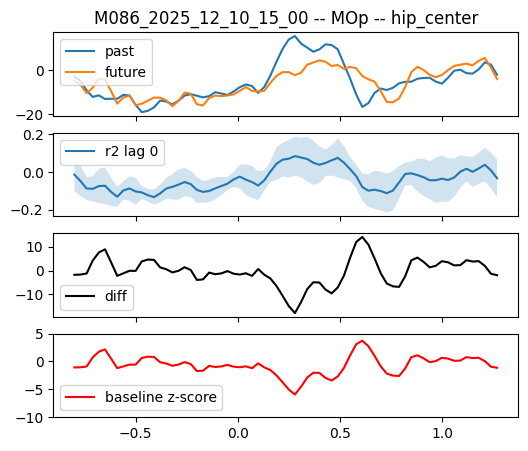

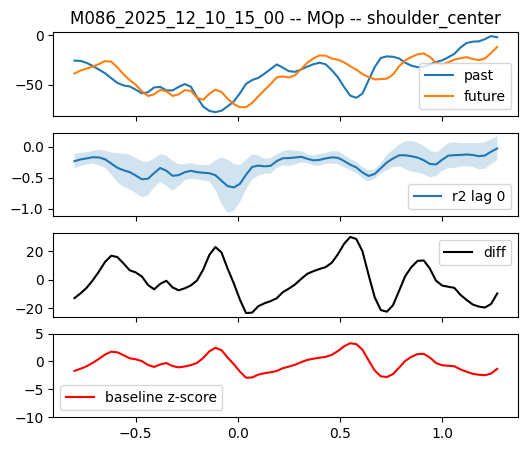

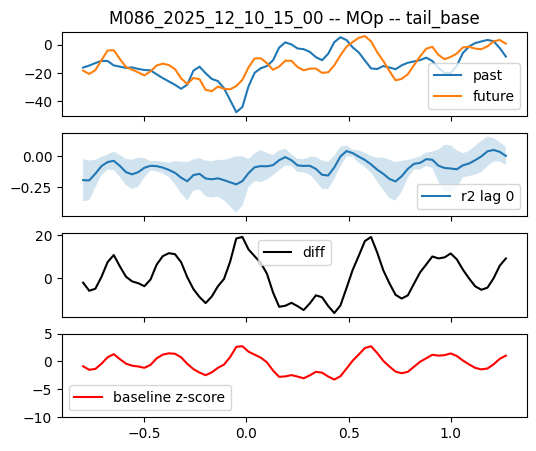

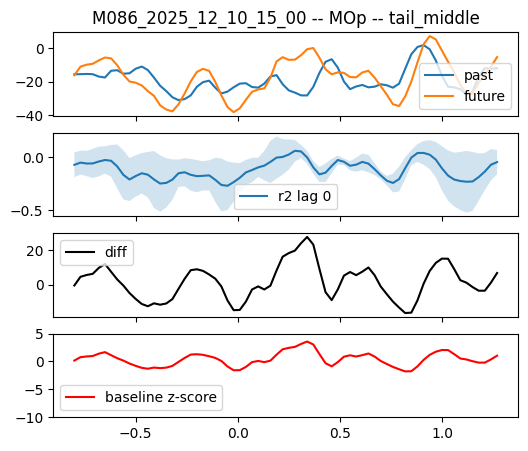

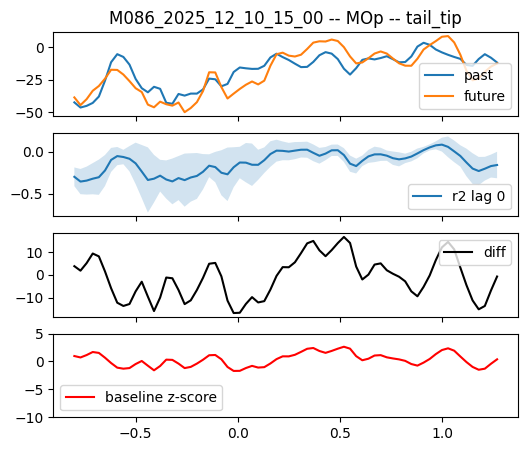

In [505]:
area = 'MOp'
BASELINE_S = (-0.8, -.3)
bl_mask = (t_all >= BASELINE_S[0]) & (t_all < BASELINE_S[1])
KP_ORDER = [
    'left_paw',  'left_wrist',  'left_elbow',  'left_shoulder',
    'right_paw', 'right_wrist', 'right_elbow', 'right_shoulder',
    'left_foot',  'left_ankle',  'left_knee',
    'right_foot', 'right_ankle', 'right_knee',
    'hip_center', 'shoulder_center', 'tail_base', 'tail_middle', 'tail_tip',
]
heatmaps = []
for sess in SESSIONS_ALL:
    heatmap_dict = {}

    for kp in KP_ORDER:
        data, lags_ms = _load_session_for_area(area, sess)
        lag_mask, lags_masked, past_mask, future_mask = _make_masks(lags_ms)
        lag0_idx = np.argmin(np.abs(lags_masked))

        res   = data[kp]
        t_all = np.array(sorted(res.keys()))
        ap, af, r2_0 = [], [], []

        for ti in t_all:
            curve = res[ti].mean(-1)[lag_mask]
            ap.append(np.trapz(curve[past_mask],   lags_masked[past_mask]))
            af.append(np.trapz(curve[future_mask], lags_masked[future_mask]))
            r2_0.append(res[ti][lag0_idx])
        ap, af, r2_0 = np.array(ap), np.array(af), np.array(r2_0)
        diff = af - ap
        bl_z_diff = (diff - diff[bl_mask].mean()) / diff[bl_mask].std()

        heatmap_dict[kp] = bl_z_diff

        fig, axs = plt.subplots(4, 1, figsize=(6, 5), sharex='all')
        axs[0].plot(t_all, ap, label='past')
        axs[0].plot(t_all, af, label='future')
        axs[0].legend()
        vizutils.shaded_errorbar(axs[1], t_all, r2_0, label='r2 lag 0')
        # axs[1].plot(t_all, r2_0, label='r2 lag 0', color='g')
        axs[1].legend()
        axs[2].plot(t_all, af-ap, label='diff', color='k')
        axs[2].legend()

        axs[3].plot(t_all, bl_z_diff, label='baseline z-score', color='r')
        axs[3].set_ylim(-10, 5)
        axs[3].legend()

        axs[0].set_title(f'{sess} -- {area} -- {kp}')

    heatmap = np.array([heatmap_dict[kp] for kp in KP_ORDER])
    heatmaps.append(heatmap)
# heatmaps = np.array(heatmaps)
# heatmap_across_sess = heatmaps.mean(0)
# fig, ax = plt.subplots(figsize=(12, 7))
# im = ax.imshow(heatmap_across_sess, aspect='auto', cmap='coolwarm',
#                vmin=-4, vmax=4, 
#                extent=[t_all[0], t_all[-1], len(KP_ORDER) - 0.5, -0.5]
#                )
# ax.set_yticks(range(len(KP_ORDER)))
# ax.set_yticklabels(KP_ORDER)
# ax.axvline(0, color='k', linestyle='dashed')
# fig.colorbar(im, ax=ax, label='z-score  (− = reactive dominates)')


In [386]:
heatmaps.shape

(9, 19, 70)

In [25]:
SESSIONS_ALL = [
    'M061_2025_03_04_10_00',
    'M061_2025_03_05_14_00',
    'M061_2025_03_06_14_00',
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    # 'M063_2025_03_13_14_00',
    # 'M063_2025_03_14_15_30',
    'M078_2025_08_06_15_00',
    'M086_2025_12_10_15_00',
]

M061_2025_03_04_10_00: r=0.020, p=0.9363
M061_2025_03_05_14_00: r=-0.487, p=0.0344
M061_2025_03_06_14_00: r=-0.743, p=0.0003
M062_2025_03_20_14_00: r=-0.465, p=0.0450
M062_2025_03_21_14_00: r=0.142, p=0.5612
M078_2025_08_06_15_00: r=0.175, p=0.4738
M086_2025_12_10_15_00: r=-0.549, p=0.0149


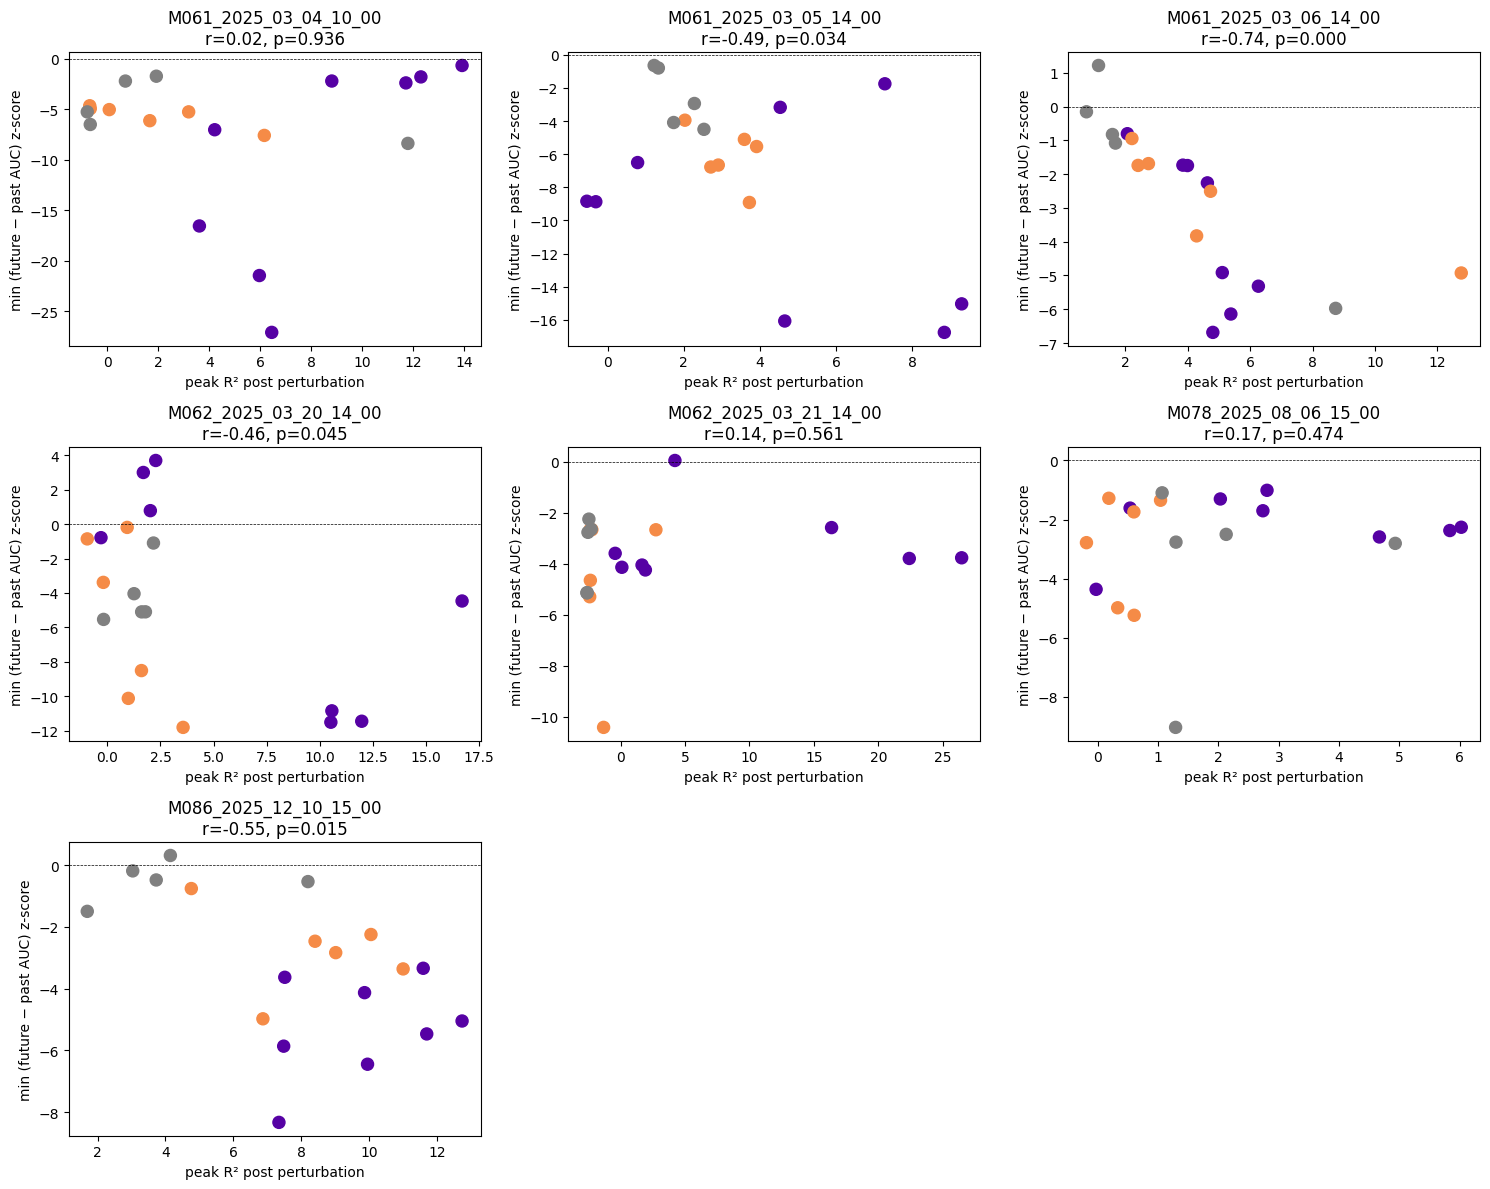

In [26]:
from scipy.stats import pearsonr

area       = 'SSp'
BASELINE_S = (-0.8, -.3)
POST_S     = (0.05,  0.6)
KP_ORDER   = [
    'left_paw',  'left_wrist',  'left_elbow',  'left_shoulder',
    'right_paw', 'right_wrist', 'right_elbow', 'right_shoulder',
    'left_foot',  'left_ankle',  'left_knee',
    'right_foot', 'right_ankle', 'right_knee',
    'hip_center', 'shoulder_center', 'tail_base', 'tail_middle', 'tail_tip',
]

FORELIMBS  = {'left_paw', 'left_wrist', 'left_elbow', 'left_shoulder',
              'right_paw', 'right_wrist', 'right_elbow', 'right_shoulder'}
HINDLIMBS  = {'left_foot', 'left_ankle', 'left_knee',
              'right_foot', 'right_ankle', 'right_knee'}
KP_COLORS  = [plt.cm.plasma(0.15) if kp in FORELIMBS else
              plt.cm.plasma(0.72) if kp in HINDLIMBS else
              'grey'
              for kp in KP_ORDER]

ncols = 3
nrows = int(np.ceil(len(SESSIONS_ALL) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).flatten()

for ax_i, sess in enumerate(SESSIONS_ALL):
    peak_r2  = []
    min_diff = []

    for kp in KP_ORDER:
        data, lags_ms = _load_session_for_area(area, sess)
        lag_mask, lags_masked, past_mask, future_mask = _make_masks(lags_ms)
        lag0_idx = np.argmin(np.abs(lags_masked))

        res   = data[kp]
        t_all = np.array(sorted(res.keys()))
        bl_mask   = (t_all >= BASELINE_S[0]) & (t_all < BASELINE_S[1])
        post_mask = (t_all >= POST_S[0])     & (t_all < POST_S[1])

        ap, af, r2_0 = [], [], []
        for ti in t_all:
            curve = res[ti].mean(-1)[lag_mask]
            ap.append(np.trapz(curve[past_mask],   lags_masked[past_mask]))
            af.append(np.trapz(curve[future_mask], lags_masked[future_mask]))
            r2_0.append(curve[lag0_idx])
        ap, af, r2_0 = np.array(ap), np.array(af), np.array(r2_0)
        diff = af - ap
        bl_z_diff = (diff - diff[bl_mask].mean()) / diff[bl_mask].std()

        bl_z_r0 = (r2_0 - r2_0[bl_mask].mean()) / r2_0[bl_mask].std()
        peak_r2.append(bl_z_r0[post_mask].max())
        min_diff.append(bl_z_diff[post_mask].min())

    peak_r2  = np.array(peak_r2)
    min_diff = np.array(min_diff)
    r, p = pearsonr(peak_r2, min_diff)
    print(f'{sess}: r={r:.3f}, p={p:.4f}')

    ax = axes[ax_i]
    ax.scatter(peak_r2, min_diff, s=75, c=KP_COLORS)
    ax.set_xlabel('peak R² post perturbation')
    ax.set_ylabel('min (future − past AUC) z-score')
    ax.set_title(f'{sess}\nr={r:.2f}, p={p:.3f}')
    ax.axhline(0, color='k', lw=0.5, linestyle='dashed')

for ax in axes[len(SESSIONS_ALL):]:
    ax.set_visible(False)
plt.tight_layout()

In [534]:
area

'MOp'

In [34]:
SESSIONS_ALL = [
    'M061_2025_03_04_10_00',
    'M061_2025_03_05_14_00',
    'M061_2025_03_06_14_00',
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    # 'M063_2025_03_13_14_00',
    # 'M063_2025_03_14_15_30',
    'M078_2025_08_06_15_00',
    'M086_2025_12_10_15_00',
]

All sessions pooled: r=-0.143, p=0.1001, n=133


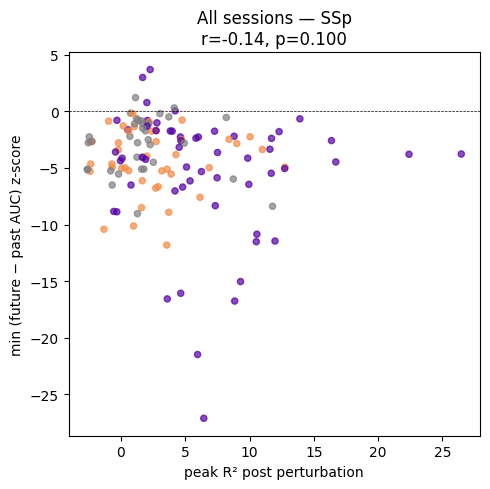

In [31]:
all_peak_r2  = []
all_min_diff = []
all_colors   = []
area = 'SSp'
for sess in SESSIONS_ALL:
    for kp, color in zip(KP_ORDER, KP_COLORS):
        data, lags_ms = _load_session_for_area(area, sess)
        lag_mask, lags_masked, past_mask, future_mask = _make_masks(lags_ms)
        lag0_idx = np.argmin(np.abs(lags_masked))

        res   = data[kp]
        t_all = np.array(sorted(res.keys()))
        bl_mask   = (t_all >= BASELINE_S[0]) & (t_all < BASELINE_S[1])
        post_mask = (t_all >= POST_S[0])     & (t_all < POST_S[1])

        ap, af, r2_0 = [], [], []
        for ti in t_all:
            curve = res[ti].mean(-1)[lag_mask]
            ap.append(np.trapz(curve[past_mask],   lags_masked[past_mask]))
            af.append(np.trapz(curve[future_mask], lags_masked[future_mask]))
            r2_0.append(curve[lag0_idx])
        ap, af, r2_0 = np.array(ap), np.array(af), np.array(r2_0)
        diff = af - ap
        bl_z_diff = (diff - diff[bl_mask].mean()) / diff[bl_mask].std()
        bl_z_r0   = (r2_0 - r2_0[bl_mask].mean()) / r2_0[bl_mask].std()

        all_peak_r2.append(bl_z_r0[post_mask].max())
        all_min_diff.append(bl_z_diff[post_mask].min())
        all_colors.append(color)

all_peak_r2  = np.array(all_peak_r2)
all_min_diff = np.array(all_min_diff)
r, p = pearsonr(all_peak_r2, all_min_diff)
print(f'All sessions pooled: r={r:.3f}, p={p:.4f}, n={len(all_peak_r2)}')

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(all_peak_r2, all_min_diff, s=20, c=all_colors, alpha=0.7)
ax.set_xlabel('peak R² post perturbation')
ax.set_ylabel('min (future − past AUC) z-score')
ax.set_title(f'All sessions — {area}\nr={r:.2f}, p={p:.3f}')
ax.axhline(0, color='k', lw=0.5, linestyle='dashed')
plt.tight_layout()

In [32]:
import pandas as pd
import statsmodels.formula.api as smf

# Build dataframe from the pooled arrays computed above
df_lme = pd.DataFrame({
    'peak_r2' : all_peak_r2,
    'min_diff': all_min_diff,
    'session' : [s   for s  in SESSIONS_ALL for _  in KP_ORDER],
    'keypoint': [kp  for _  in SESSIONS_ALL for kp in KP_ORDER],
    'animal'  : [s.split('_')[0] for s in SESSIONS_ALL for _ in KP_ORDER],
})

# Mixed model:
#   fixed effect  : peak_r2
#   random intercept per animal   (groups=)
#   random intercept per keypoint (vc_formula=) — crossed with animal
model = smf.mixedlm(
    'min_diff ~ peak_r2',
    df_lme,
    groups=df_lme['animal'],
    vc_formula={'keypoint': '0 + C(keypoint)'},
)
result = model.fit(reml=True)
print(result.summary())

beta  = result.params['peak_r2']
se    = result.bse['peak_r2']
z     = result.tvalues['peak_r2']
p_lme = result.pvalues['peak_r2']
print(f'\npeak_r2 fixed effect:  beta={beta:.3f}, SE={se:.3f}, z={z:.2f}, p={p_lme:.4f}')

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: min_diff 
No. Observations: 133     Method:             REML     
No. Groups:       4       Scale:              13.7028  
Min. group size:  19      Log-Likelihood:     -380.2294
Max. group size:  57      Converged:          Yes      
Mean group size:  33.2                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    -3.979    0.522 -7.621 0.000 -5.002 -2.955
peak_r2      -0.067    0.080 -0.830 0.407 -0.224  0.091
keypoint Var  4.543    0.632                           


peak_r2 fixed effect:  beta=-0.067, SE=0.080, z=-0.83, p=0.4067


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

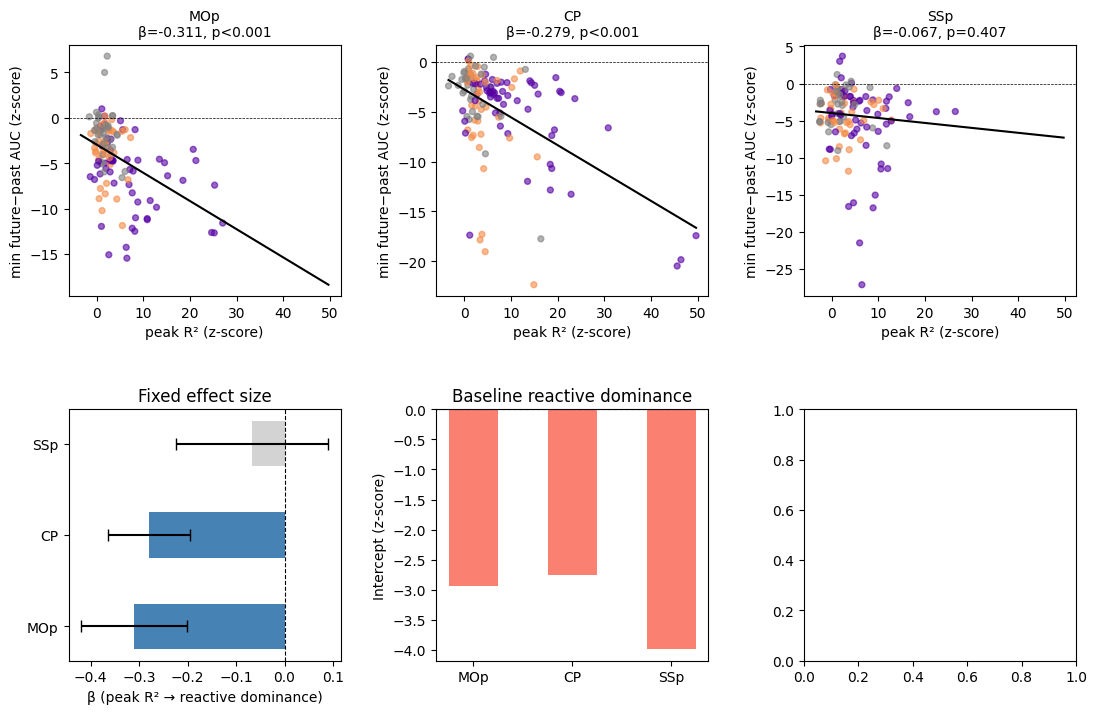

In [35]:
AREAS_PLOT = ['MOp', 'CP', 'SSp']

# ── collect data & fit LME per area ──────────────────────────────────────────
area_data   = {}   # area → (peak_r2, min_diff) arrays
area_lme    = {}   # area → fitted result

for area_i in AREAS_PLOT:
    pr2, md = [], []
    for sess in SESSIONS_ALL:
        for kp in KP_ORDER:
            data, lags_ms = _load_session_for_area(area_i, sess)
            lag_mask, lags_masked, past_mask, future_mask = _make_masks(lags_ms)
            lag0_idx = np.argmin(np.abs(lags_masked))

            res   = data[kp]
            t_all = np.array(sorted(res.keys()))
            bl_mask   = (t_all >= BASELINE_S[0]) & (t_all < BASELINE_S[1])
            post_mask = (t_all >= POST_S[0])     & (t_all < POST_S[1])

            ap, af, r2_0 = [], [], []
            for ti in t_all:
                curve = res[ti].mean(-1)[lag_mask]
                ap.append(np.trapz(curve[past_mask],   lags_masked[past_mask]))
                af.append(np.trapz(curve[future_mask], lags_masked[future_mask]))
                r2_0.append(curve[lag0_idx])
            ap, af, r2_0 = np.array(ap), np.array(af), np.array(r2_0)
            diff      = af - ap
            bl_z_diff = (diff  - diff[bl_mask].mean())  / diff[bl_mask].std()
            bl_z_r0   = (r2_0  - r2_0[bl_mask].mean())  / r2_0[bl_mask].std()
            pr2.append(bl_z_r0[post_mask].max())
            md.append(bl_z_diff[post_mask].min())

    pr2, md = np.array(pr2), np.array(md)
    area_data[area_i] = (pr2, md)

    df_a = df_lme.copy()
    df_a['peak_r2']  = pr2
    df_a['min_diff'] = md
    area_lme[area_i] = smf.mixedlm(
        'min_diff ~ peak_r2', df_a,
        groups=df_a['animal'],
        vc_formula={'keypoint': '0 + C(keypoint)'},
    ).fit(reml=True)

# ── figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 8))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

ax_scatter = [fig.add_subplot(gs[0, i]) for i in range(3)]
ax_beta    = fig.add_subplot(gs[1, 0])
ax_intcp   = fig.add_subplot(gs[1, 1])
ax_kpvar   = fig.add_subplot(gs[1, 2])

x_range = np.linspace(
    min(area_data[a][0].min() for a in AREAS_PLOT),
    max(area_data[a][0].max() for a in AREAS_PLOT), 100
)

for ax, area_i in zip(ax_scatter, AREAS_PLOT):
    pr2, md = area_data[area_i]
    res     = area_lme[area_i]
    b0      = res.params['Intercept']
    b1      = res.params['peak_r2']
    p       = res.pvalues['peak_r2']
    p_str   = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'

    ax.scatter(pr2, md, s=18, c=KP_COLORS * len(SESSIONS_ALL), alpha=0.6)
    ax.plot(x_range, b0 + b1 * x_range, color='k', lw=1.5)
    ax.axhline(0, color='k', lw=0.5, linestyle='dashed')
    ax.set_title(f'{area_i}\nβ={b1:.3f}, {p_str}', fontsize=10)
    ax.set_xlabel('peak R² (z-score)')
    ax.set_ylabel('min future−past AUC (z-score)')

# forest plot — betas with 95% CI
betas  = [area_lme[a].params['peak_r2']   for a in AREAS_PLOT]
ci_lo  = [area_lme[a].conf_int().loc['peak_r2', 0] for a in AREAS_PLOT]
ci_hi  = [area_lme[a].conf_int().loc['peak_r2', 1] for a in AREAS_PLOT]
y_pos  = np.arange(len(AREAS_PLOT))

ax_beta.barh(y_pos, betas, xerr=[np.array(betas)-np.array(ci_lo),
                                  np.array(ci_hi)-np.array(betas)],
             color=['steelblue' if area_lme[a].pvalues['peak_r2'] < 0.05 else 'lightgrey'
                    for a in AREAS_PLOT],
             capsize=4, height=0.5)
ax_beta.axvline(0, color='k', lw=0.8, linestyle='dashed')
ax_beta.set_yticks(y_pos); ax_beta.set_yticklabels(AREAS_PLOT)
ax_beta.set_xlabel('β (peak R² → reactive dominance)')
ax_beta.set_title('Fixed effect size')

# intercepts — overall reactive dominance level per area
intcps = [area_lme[a].params['Intercept'] for a in AREAS_PLOT]
ax_intcp.bar(AREAS_PLOT, intcps, color='salmon', width=0.5)
ax_intcp.axhline(0, color='k', lw=0.8, linestyle='dashed')
ax_intcp.set_ylabel('Intercept (z-score)')
ax_intcp.set_title('Baseline reactive dominance')

# keypoint variance
kpvars = [area_lme[a].vcomp['keypoint'] for a in AREAS_PLOT]
ax_kpvar.bar(AREAS_PLOT, kpvars, color='mediumpurple', width=0.5)
ax_kpvar.set_ylabel('Variance')
ax_kpvar.set_title('Keypoint random effect')

for ax in [ax_beta, ax_intcp, ax_kpvar]:
    ax.spines[['top', 'right']].set_visible(False)

print('area   beta    CI_lo   CI_hi    p')
for a in AREAS_PLOT:
    r = area_lme[a]
    ci = r.conf_int().loc['peak_r2']
    print(f'{a:4s}  {r.params["peak_r2"]:+.3f}  {ci[0]:+.3f}  {ci[1]:+.3f}  {r.pvalues["peak_r2"]:.4f}')

plt.suptitle(f'Peak R² vs reactive dominance — {area} sessions', fontsize=11)
plt.tight_layout()

MOp  Forelimb   peak_r2=+7.38±0.97  min_diff=-6.34±0.55
MOp  Hindlimb   peak_r2=+2.11±0.31  min_diff=-3.57±0.45
MOp  Axial      peak_r2=+1.77±0.29  min_diff=-1.64±0.46

CP   Forelimb   peak_r2=+11.69±1.47  min_diff=-5.34±0.63
CP   Hindlimb   peak_r2=+4.14±0.58  min_diff=-5.17±0.83
CP   Axial      peak_r2=+2.36±0.66  min_diff=-3.01±0.56

SSp  Forelimb   peak_r2=+6.58±0.75  min_diff=-5.41±0.77
SSp  Hindlimb   peak_r2=+2.58±0.57  min_diff=-4.37±0.43
SSp  Axial      peak_r2=+1.76±0.52  min_diff=-2.95±0.42



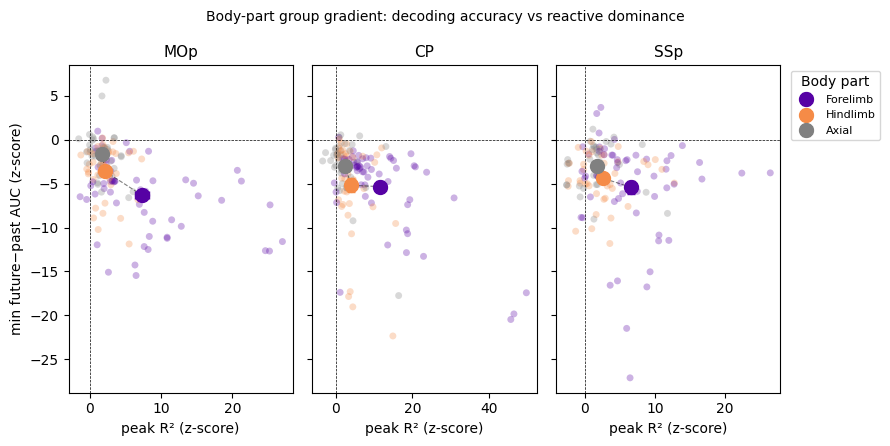

In [ ]:
from scipy.stats import sem

# Body-part group membership (same sets as KP_COLORS)
HINDLIMBS = {'left_foot', 'left_ankle', 'left_knee',
             'right_foot', 'right_ankle', 'right_knee'}
AXIAL     = {'hip_center', 'shoulder_center', 'tail_base', 'tail_middle', 'tail_tip'}

def kp_group(kp):
    if kp in FORELIMBS: return 'Forelimb'
    if kp in HINDLIMBS: return 'Hindlimb'
    return 'Axial'

GROUP_COLOR = {
    'Forelimb': plt.cm.plasma(0.15),
    'Hindlimb': plt.cm.plasma(0.72),
    'Axial':    'grey',
}
GROUP_ORDER = ['Forelimb', 'Hindlimb', 'Axial']

# keypoint → group label, reused across areas
kp_groups = np.array([kp_group(kp) for kp in KP_ORDER * len(SESSIONS_ALL)])

fig, axes = plt.subplots(1, len(AREAS_PLOT), figsize=(3 * len(AREAS_PLOT), 4.5),
                         sharex=False, sharey=True)

for ax, area_i in zip(axes, AREAS_PLOT):
    pr2, md = area_data[area_i]

    # individual points (small, faded)
    ax.scatter(pr2, md, s=25, c=KP_COLORS * len(SESSIONS_ALL), alpha=0.3, linewidths=0)

    # group means ± SEM, connected by a line to show gradient
    gx, gy = [], []
    for grp in GROUP_ORDER:
        mask = kp_groups == grp
        mx, my = pr2[mask].mean(), md[mask].mean()
        sx, sy = sem(pr2[mask]),   sem(md[mask])
        gx.append(mx); gy.append(my)
        ax.errorbar(mx, my, xerr=sx, yerr=sy,
                    fmt='o', ms=10, color=GROUP_COLOR[grp],
                    ecolor=GROUP_COLOR[grp], elinewidth=1.5, capsize=3,
                    label=grp, zorder=5)
        print(f'{area_i:4s} {grp:9s}  peak_r2={mx:+.2f}±{sx:.2f}  min_diff={my:+.2f}±{sy:.2f}')

    # connect group means to show gradient
    ax.plot(gx, gy, color='k', lw=0.8, linestyle='dashed', zorder=4, alpha=0.5)

    ax.axhline(0, color='k', lw=0.5, linestyle='dashed')
    ax.axvline(0, color='k', lw=0.5, linestyle='dashed')
    ax.set_xlabel('peak R² (z-score)')
    ax.set_title(area_i, fontsize=11)
    print()

axes[0].set_ylabel('min future−past AUC (z-score)')
axes[-1].legend(title='Body part', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.suptitle('Body-part group gradient: decoding accuracy vs reactive dominance', fontsize=10)
plt.tight_layout()

MOp Forelimb   R²=+7.38±2.05  diff=-6.34±1.34
MOp Hindlimb   R²=+2.11±0.73  diff=-3.57±0.65
MOp Axial      R²=+1.77±0.43  diff=-1.64±0.74

CP Forelimb   R²=+11.69±3.15  diff=-5.34±1.02
CP Hindlimb   R²=+4.14±1.36  diff=-5.17±1.49
CP Axial      R²=+2.36±0.84  diff=-3.01±0.74

SSp Forelimb   R²=+6.58±0.99  diff=-5.41±1.18
SSp Hindlimb   R²=+2.58±1.22  diff=-4.37±0.59
SSp Axial      R²=+1.76±0.79  diff=-2.95±0.59



/tmp/ipykernel_1318930/2015565485.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


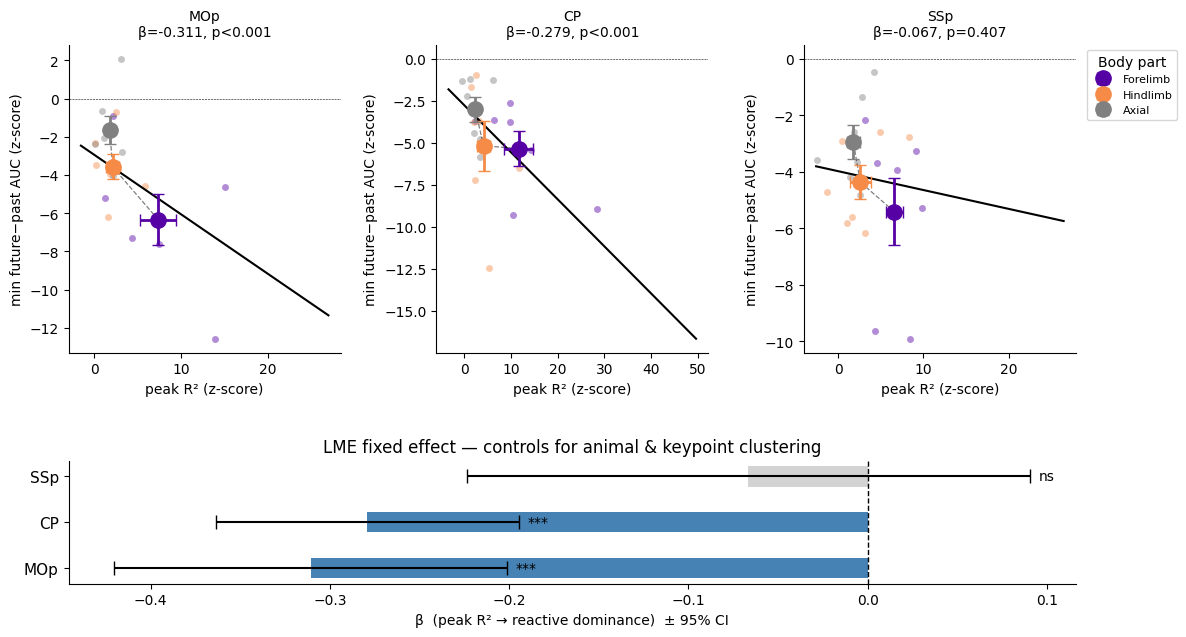

In [36]:
from scipy.stats import sem

HINDLIMBS = {'left_foot', 'left_ankle', 'left_knee',
             'right_foot', 'right_ankle', 'right_knee'}
AXIAL     = {'hip_center', 'shoulder_center', 'tail_base', 'tail_middle', 'tail_tip'}

def kp_group(kp):
    if kp in FORELIMBS: return 'Forelimb'
    if kp in HINDLIMBS: return 'Hindlimb'
    return 'Axial'

GROUP_COLOR = {'Forelimb': plt.cm.plasma(0.15),
               'Hindlimb': plt.cm.plasma(0.72),
               'Axial':    'grey'}
GROUP_ORDER   = ['Forelimb', 'Hindlimb', 'Axial']
kp_grp_single = np.array([kp_group(kp) for kp in KP_ORDER])
n_kp, n_sess  = len(KP_ORDER), len(SESSIONS_ALL)

fig = plt.figure(figsize=(13, 7))
gs  = fig.add_gridspec(2, 3, height_ratios=[2.5, 1], hspace=0.5, wspace=0.35)
ax_scatter = [fig.add_subplot(gs[0, i]) for i in range(3)]
ax_forest  = fig.add_subplot(gs[1, :])

for ax, area_i in zip(ax_scatter, AREAS_PLOT):
    pr2, md = area_data[area_i]
    pr2_mat = pr2.reshape(n_sess, n_kp)
    md_mat  = md.reshape(n_sess, n_kp)

    gx_grand, gy_grand = [], []
    for grp in GROUP_ORDER:
        mask = kp_grp_single == grp
        # session-level means (unit of replication = session)
        sx = pr2_mat[:, mask].mean(axis=1)   # (n_sess,)
        sy = md_mat[:,  mask].mean(axis=1)

        # individual session points (small)
        ax.scatter(sx, sy, s=25, color=GROUP_COLOR[grp], alpha=0.45, linewidths=0)

        # grand mean ± SEM across sessions
        mx, my = sx.mean(), sy.mean()
        ex, ey = sem(sx), sem(sy)
        ax.errorbar(mx, my, xerr=ex, yerr=ey,
                    fmt='o', ms=11, color=GROUP_COLOR[grp],
                    ecolor=GROUP_COLOR[grp], elinewidth=2, capsize=4,
                    label=grp, zorder=5)
        gx_grand.append(mx); gy_grand.append(my)
        print(f'{area_i} {grp:9s}  R²={mx:+.2f}±{ex:.2f}  diff={my:+.2f}±{ey:.2f}')

    # dashed line connecting group grand means (shows gradient)
    ax.plot(gx_grand, gy_grand, 'k--', lw=0.9, alpha=0.5, zorder=4)

    # LME regression line (uses full fixed effect)
    res = area_lme[area_i]
    b0, b1 = res.params['Intercept'], res.params['peak_r2']
    xl = np.array([pr2.min(), pr2.max()])
    ax.plot(xl, b0 + b1 * xl, color='k', lw=1.5, zorder=3)

    p     = res.pvalues['peak_r2']
    p_str = 'p<0.001' if p < 0.001 else f'p={p:.3f}'
    ax.set_title(f'{area_i}\nβ={b1:.3f}, {p_str}', fontsize=10)
    ax.axhline(0, color='k', lw=0.4, linestyle='dashed')
    ax.set_xlabel('peak R² (z-score)')
    ax.set_ylabel('min future−past AUC (z-score)')
    ax.spines[['top', 'right']].set_visible(False)
    print()

ax_scatter[-1].legend(title='Body part', bbox_to_anchor=(1.02, 1),
                      loc='upper left', fontsize=8)

# ── forest plot of betas ──────────────────────────────────────────────────────
betas  = [area_lme[a].params['peak_r2'] for a in AREAS_PLOT]
ci_lo  = [area_lme[a].conf_int().loc['peak_r2', 0] for a in AREAS_PLOT]
ci_hi  = [area_lme[a].conf_int().loc['peak_r2', 1] for a in AREAS_PLOT]
pvals  = [area_lme[a].pvalues['peak_r2'] for a in AREAS_PLOT]
y_pos  = np.arange(len(AREAS_PLOT))
colors = ['steelblue' if p < 0.05 else 'lightgrey' for p in pvals]

ax_forest.barh(y_pos, betas,
               xerr=[np.array(betas) - np.array(ci_lo),
                     np.array(ci_hi)  - np.array(betas)],
               color=colors, capsize=5, height=0.45)
ax_forest.axvline(0, color='k', lw=1, linestyle='dashed')
ax_forest.set_yticks(y_pos)
ax_forest.set_yticklabels(AREAS_PLOT, fontsize=11)
ax_forest.set_xlabel('β  (peak R² → reactive dominance)  ± 95% CI')
ax_forest.set_title('LME fixed effect — controls for animal & keypoint clustering')
ax_forest.spines[['top', 'right']].set_visible(False)

for i, (b, p) in enumerate(zip(betas, pvals)):
    label = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ax_forest.text(ci_hi[i] + 0.005, i, label, va='center', fontsize=10)

plt.tight_layout()

In [89]:
SESSIONS_ALL = [
    # 'M061_2025_03_04_10_00',
    # 'M061_2025_03_05_14_00',
    # 'M061_2025_03_06_14_00',
    # 'M062_2025_03_20_14_00',
    # 'M062_2025_03_21_14_00',
    # 'M063_2025_03_13_14_00',
    # 'M063_2025_03_14_15_30',
    'M078_2025_08_06_15_00',
    # 'M086_2025_12_10_15_00',
]

M078_2025_08_06_15_00: left forelimb drift at t=0 → 1.0 ms

Grand mean drift at t=0: 1.05 ms


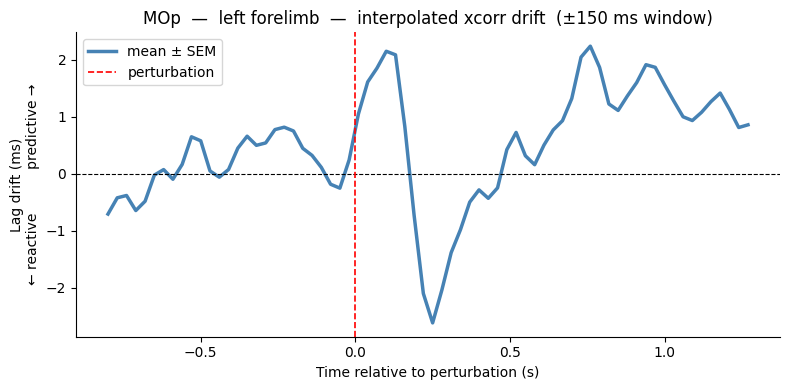

In [90]:
from scipy.signal import correlate
from scipy.stats import sem

DRIFT_LAG_WINDOW = (-150, 150)   # ms — analysis window for xcorr

LEFT_FORELIMBS = {'left_paw', 'left_wrist', 'left_elbow', 'left_shoulder'}

def _compute_drift(curve, baseline, lags):
    """Interpolated xcorr peak shift (ms). Positive = predictive, negative = reactive."""
    c  = curve    / (curve.max()    + 1e-12)
    b  = baseline / (baseline.max() + 1e-12)
    xc = correlate(c, b, mode='full')
    step = lags[1] - lags[0]
    pk   = xc.argmax()
    if 0 < pk < len(xc) - 1:
        y0, y1, y2 = xc[pk - 1], xc[pk], xc[pk + 1]
        delta = 0.5 * (y0 - y2) / (y0 - 2 * y1 + y2 + 1e-12)
        return (pk + delta) * step - (len(lags) - 1) * step
    return (pk - (len(lags) - 1)) * step

# ── compute drift per session (averaged across left forelimbs) ───────────────
all_drift_sessions = []
t_all_ref = None

for sess in SESSIONS_ALL:
    data, lags_ms = _load_session_for_area(area, sess)

    drift_lag_mask = (lags_ms >= DRIFT_LAG_WINDOW[0]) & (lags_ms <= DRIFT_LAG_WINDOW[1])
    lags_drift     = lags_ms[drift_lag_mask]

    forelimb_drifts = []
    for kp in LEFT_FORELIMBS:
        if kp not in data:
            continue
        res   = data[kp]
        t_all = np.array(sorted(res.keys()))
        if t_all_ref is None:
            t_all_ref = t_all

        bl_mask       = (t_all >= BASELINE_S[0]) & (t_all < BASELINE_S[1])
        bl_curves     = np.array([res[ti].mean(-1)[drift_lag_mask] for ti in t_all[bl_mask]])
        baseline_mean = bl_curves.mean(0)

        drift = np.array([
            _compute_drift(res[ti].mean(-1)[drift_lag_mask], baseline_mean, lags_drift)
            for ti in t_all
        ])
        forelimb_drifts.append(drift)

    all_drift_sessions.append(np.mean(forelimb_drifts, axis=0))
    print(f'{sess}: left forelimb drift at t=0 → '
          f'{all_drift_sessions[-1][np.argmin(np.abs(t_all_ref))]:.1f} ms')

all_drift_sessions = np.array(all_drift_sessions)   # (n_sess, n_times)
drift_mean = all_drift_sessions.mean(0)
drift_sem  = sem(all_drift_sessions, axis=0)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

for sess_drift in all_drift_sessions:
    ax.plot(t_all_ref, sess_drift, color='steelblue', lw=0.8, alpha=0.3)

ax.fill_between(t_all_ref, drift_mean - drift_sem, drift_mean + drift_sem,
                color='steelblue', alpha=0.35)
ax.plot(t_all_ref, drift_mean, color='steelblue', lw=2.5, label='mean ± SEM')

ax.axhline(0, color='k', lw=0.8, linestyle='dashed')
ax.axvline(0, color='r', lw=1.2, linestyle='dashed', label='perturbation')
ax.set_xlabel('Time relative to perturbation (s)')
ax.set_ylabel('Lag drift (ms)\n← reactive          predictive →')
ax.set_title(f'{area}  —  left forelimb  —  interpolated xcorr drift  (±{DRIFT_LAG_WINDOW[1]} ms window)')
ax.spines[['top', 'right']].set_visible(False)
ax.legend()
plt.tight_layout()

print(f'\nGrand mean drift at t=0: {drift_mean[np.argmin(np.abs(t_all_ref))]:.2f} ms')

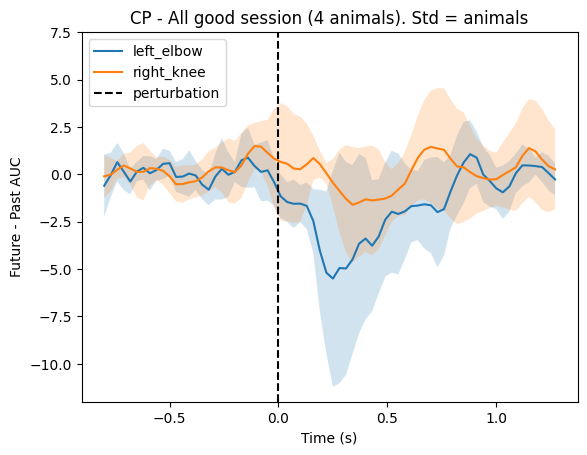

In [62]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, t_all, heatmaps[:, 0, :].T, label='left_elbow')
vizutils.shaded_errorbar(ax, t_all, heatmaps[:, 13, :].T, label='right_knee')
ax.axvline(0, color='k', linestyle='dashed',label='perturbation')
ax.set_title('CP - All good session (4 animals). Std = animals')
ax.set_ylabel('Future - Past AUC')
ax.set_xlabel('Time (s)')
ax.set_ylim(-12, 7.5)
ax.legend()